# MetAIsAFe v4.0 — Notebook de validation
## Pipeline B2 : STEP 1 → STEP 8

**Objectif** : valider chaque étape du pipeline séquentiellement, avec des assertions et des diagnostics visuels à chaque transition.

| Cellule | Étape | Module(s) |
|---------|-------|-----------|
| [0] | Setup & logging | — |
| [1] | Chargement & préparation | `loader`, `preparation` |
| [2] | Filtrage populations | `preparation` |
| [3] | Split train/test + CV | `splitter` |
| [4] | Encodage & winsorisation | `loader`, `preprocessing` |
| [5a] | Classifieurs CLF1 / CLF2 | `classifiers`, `trainer` |
| [5b] | Stage 1 — carbonStem | `models`, `trainer` |
| [5c] | Stage 2 — yield | `models`, `trainer` |
| [6] | SHAP | `shap_analysis` |
| [7] | Évaluation finale | `evaluator` |
| [8] | Inférence test | `predictor` |

---
## [0] Setup & logging

In [1]:
import sys
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Project root ─────────────────────────────────────────────────────────────
# Adapter si le notebook n'est pas à la racine du projet
PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root : {PROJECT_ROOT}")

# ── Logging ──────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)
log = logging.getLogger("metaisafe.notebook")

# ── Imports projet ────────────────────────────────────────────────────────────
from config import (
    get_campaign_paths,
    RANDOM_STATE,
    TREE_FAIL_THRESHOLD,
    YIELD_FAIL_THRESHOLD,
    YIELD_FAIL_RATE,
    SEQUENTIAL_TARGETS_STAGE1,
    SEQUENTIAL_TARGETS_STAGE2,
)
from column_taxonomy import (
    ACTIVE_FEATURES_B2,
    CATEGORICAL_FEATURES_B2,
    STOCK_TARGETS_MINIMAL,
    NOMINAL_POPULATION,
)
from data.loader import load_data, encode_categoricals, build_dataset
from data.preparation import (
    add_derived_columns, filter_crops, clean,
    compute_effective_vars, filter_population,
)
from data.preprocessing import apply_winsorization
from data.splitter import (
    stratified_split_by_rotation,
    build_cv_groups, make_group_kfold,
    summarise_rotations,
)
from modeling.models import build_lgb, build_lgb_classifier
from modeling.trainer import cross_validate, train_final_model, train_classifier
from modeling.classifiers import (
    build_tree_fail_classifier,
    build_yield_fail_classifier,
    evaluate_classifier,
    save_classifiers, load_classifiers,
    CLF1_FEATURES, CLF2_FEATURES,
    predict_routing,
)
from modeling.evaluator import compute_metrics, plot_pred_vs_obs
from modeling.shap_analysis import (
    run_shap_analysis,
    plot_shap_by_target,
    export_shap_for_shiny,
)
from modeling.predictor import (
    build_inference_grid, predict_single_sim, format_output,
)
from utils.io_utils import save_model, save_metrics, save_cv_results

# ── Campagne ──────────────────────────────────────────────────────────────────
CAMPAIGN_NAME = "sobol_training_1_n2048"
CV_N_FOLDS = 5
campaign = get_campaign_paths(CAMPAIGN_NAME)

log.info("Campaign : %s", campaign.campaign_name)
log.info("Models   : %s", campaign.metamodels_dir)
log.info("Data     : %s", campaign.data_dir)

Project root : D:\Documents\00.AbSys\1.MetAI-sAFe\1.Clean\MetAIsAFe
14:08:56 [INFO] metaisafe.notebook — Campaign : sobol_training_1_n2048
14:08:56 [INFO] metaisafe.notebook — Models   : D:\Documents\00.AbSys\1.MetAI-sAFe\1.Clean\MetAIsAFe\03_Models\sobol_training_1_n2048\MetaModels
14:08:56 [INFO] metaisafe.notebook — Data     : D:\Documents\00.AbSys\1.MetAI-sAFe\1.Clean\MetAIsAFe\03_Models\sobol_training_1_n2048\Data


---
## [1] STEP 1 — Chargement & préparation

**Ce qu'on valide ici :**
- Format et dimensions de la méta-table brute
- Présence des colonnes clés
- Création de `Harvest_Year_Absolute` et `Rotation`
- Filtrage culture rape
- Nettoyage conservateur
- Calcul des variables effectives

**Critères de succès :**
- `Harvest_Year_Absolute` ∈ [1, 40], entier, sans NA
- Aucune colonne clé avec >5% NA après nettoyage
- Les `_eff_` variables sont créées et positives

In [2]:
# ── 1a. Chargement brut ───────────────────────────────────────────────────────
df_raw = load_data(campaign.raw_meta)
log.info("Raw shape : %d rows × %d cols", *df_raw.shape)

# Sanity check — colonnes clés présentes
REQUIRED_COLS = [
    "SimID", "Harvest_Year_AF",
    "carbonStem_AF", "yield_AF", "yield_TA",
    "latitude", "longitude", "clay", "sand",
]
missing_raw = [c for c in REQUIRED_COLS if c not in df_raw.columns]
assert not missing_raw, f"Colonnes manquantes dans la méta-table : {missing_raw}"
log.info("✅ Toutes les colonnes clés sont présentes")

# Aperçu rapide
print(f"\nDtypes :\n{df_raw.dtypes.value_counts()}")
print(f"\nSimIDs : {df_raw['SimID'].nunique()}")
print(f"NA global : {df_raw.isna().mean().mean()*100:.1f}%")

14:08:56 [INFO] data.loader — 📂 Loading meta_table_sobol_training_1_n2048.parquet  (format: parquet, engine: pandas)
14:08:56 [INFO] data.loader — ✅ Loaded: 81800 rows × 128 columns
14:08:56 [INFO] metaisafe.notebook — Raw shape : 81800 rows × 128 cols
14:08:56 [INFO] metaisafe.notebook — ✅ Toutes les colonnes clés sont présentes

Dtypes :
float64    113
str          8
int32        4
object       3
Name: count, dtype: int64

SimIDs : 2045
NA global : 1.6%


In [3]:
# ── 1b. Colonnes dérivées ─────────────────────────────────────────────────────
df = add_derived_columns(df_raw, verbose=True)

# Validation Harvest_Year_Absolute
assert "Harvest_Year_Absolute" in df.columns, "Harvest_Year_Absolute manquant"
assert df["Harvest_Year_Absolute"].isna().sum() == 0, "NaN dans Harvest_Year_Absolute"
assert df["Harvest_Year_Absolute"].min() >= 1, "Harvest_Year_Absolute min < 1"

log.info(
    "Harvest_Year_Absolute — min=%d  max=%d  unique=%d",
    int(df["Harvest_Year_Absolute"].min()),
    int(df["Harvest_Year_Absolute"].max()),
    df["Harvest_Year_Absolute"].nunique(),
)

# Validation Rotation
if "Rotation" in df.columns:
    log.info(
        "Rotation — 0: %d  1: %d  (%.1f%% en rotation)",
        (df["Rotation"] == 0).sum(),
        (df["Rotation"] == 1).sum(),
        100.0 * df["Rotation"].mean(),
    )

# Distribution des cycles par SimID
n_cycles = df.groupby("SimID")["Harvest_Year_Absolute"].count()
log.info(
    "Cycles/SimID — min=%d  médiane=%.0f  max=%d",
    n_cycles.min(), n_cycles.median(), n_cycles.max(),
)

# Alerte si certains SimIDs ont un nombre anormal de cycles
expected_cycles = df["Harvest_Year_Absolute"].max()
incomplete = (n_cycles < expected_cycles * 0.5)
if incomplete.any():
    log.warning(
        "⚠ %d SimIDs ont moins de 50%% des cycles attendus (%d) — vérifier l'extraction",
        incomplete.sum(), expected_cycles,
    )

14:08:57 [INFO] data.preparation — Adding derived columns
14:08:57 [INFO] data.preparation —    ✓ Added 'Harvest_Year_Absolute' (normalised per SimID)
14:08:57 [INFO] data.preparation —    ✓ Added 'Rotation' flag (0 / 81800 cycles in rotation)
14:08:57 [INFO] data.preparation —    ✓ Filled 81800 NaN values in 'rot_id' with 'monoculture'
14:08:57 [INFO] metaisafe.notebook — Harvest_Year_Absolute — min=1  max=40  unique=40
14:08:57 [INFO] metaisafe.notebook — Rotation — 0: 81800  1: 0  (0.0% en rotation)
14:08:57 [INFO] metaisafe.notebook — Cycles/SimID — min=40  médiane=40  max=40


In [4]:
# ── 1c. Filtrage cultures ─────────────────────────────────────────────────────
df, crop_report = filter_crops(df, excluded_crops=["rape"], verbose=True)

if crop_report:
    log.info(
        "Crop filter — rows: %d → %d (−%.1f%%)  |  SimIDs perdus: %d",
        crop_report["n_rows_before"],
        crop_report["n_rows_after"],
        crop_report["pct_rows_lost"],
        crop_report["n_sims_lost"],
    )
    if not crop_report["detail"].empty:
        display(crop_report["detail"])

14:08:57 [INFO] data.preparation — Filtering crops: ['rape']
14:08:57 [INFO] metaisafe.notebook — Crop filter — rows: 81800 → 81800 (−0.0%)  |  SimIDs perdus: 0


In [5]:
# ── 1d. Nettoyage conservateur ────────────────────────────────────────────────
df = clean(df, verbose=True)

# Sanity check NA sur colonnes clés
na_check = df[STOCK_TARGETS_MINIMAL + ACTIVE_FEATURES_B2].isna().mean() * 100
na_high  = na_check[na_check > 5].sort_values(ascending=False)
if len(na_high):
    log.warning("Colonnes avec >5%% NA :\n%s", na_high.to_string())
else:
    log.info("✅ Aucune colonne clé avec >5%% NA")

14:08:57 [INFO] data.preparation — Cleaning (conservative)
14:08:57 [INFO] data.preparation —    ✓ Dropped 1 fully-NA columns: ['airVpd_mean_cycle_AF']
14:08:58 [INFO] data.preparation —    ✓ Clean — 81800 rows × 129 cols
14:08:58 [INFO] metaisafe.notebook — ✅ Aucune colonne clé avec >5%% NA


In [6]:
# ── 1e. Variables effectives ──────────────────────────────────────────────────
df = compute_effective_vars(df, verbose=True)

# Validation : les colonnes _eff_ sont créées et positives
eff_cols = [c for c in df.columns if "_eff_" in c]
log.info("Colonnes _eff_ créées : %s", eff_cols)
assert eff_cols, "Aucune colonne _eff_ créée — vérifier plotWidth/strip_width/density"

for col in eff_cols:
    n_neg = (df[col] < 0).sum()
    assert n_neg == 0, f"{col} contient {n_neg} valeurs négatives"
log.info("✅ Toutes les _eff_ variables sont >= 0")

# Aperçu statistique cible
display(
    df[ACTIVE_FEATURES_B2 + STOCK_TARGETS_MINIMAL]
    .describe().T.round(3)
)

14:08:58 [INFO] data.preparation — Effective variables (analytical)
14:08:58 [INFO] data.preparation —    ✓ _eff variables computed:
14:08:58 [INFO] data.preparation —      Crop : 3 AF + 3 TA
14:08:58 [INFO] data.preparation —      Tree : 3 AF + 3 TF
14:08:58 [INFO] data.preparation —      Total: 12 columns added
14:08:58 [INFO] metaisafe.notebook — Colonnes _eff_ créées : ['yield_eff_AF', 'yield_eff_TA', 'grainBiomass_eff_AF', 'grainBiomass_eff_TA', 'biomass_eff_AF', 'biomass_eff_TA', 'carbonStem_eff_AF', 'carbonStem_eff_TF', 'carbonBranches_eff_AF', 'carbonBranches_eff_TF', 'carbonCoarseRoots_eff_AF', 'carbonCoarseRoots_eff_TF']
14:08:58 [INFO] metaisafe.notebook — ✅ Toutes les _eff_ variables sont >= 0


,count,mean,std,min,25%,50%,75%,max
Harvest_Year_Absolute,81800.0,20.500,11.543,1.000,10.750,20.500,30.250,40.000
latitude,81800.0,46.002,2.887,41.000,43.500,46.000,48.500,51.000
longitude,81800.0,2.258,4.183,-5.000,-1.370,2.260,5.880,9.490
plotWidth,81800.0,13.863,4.894,5.000,10.000,15.000,18.000,20.000
plotHeight,81800.0,10.146,4.489,5.000,6.000,9.000,14.000,19.000
soilDepth,81800.0,5.001,1.733,2.000,3.500,5.000,6.500,8.000
sand,81800.0,33.279,22.820,1.020,13.930,29.120,49.350,96.520
clay,81800.0,33.388,22.873,1.000,13.820,29.690,49.690,97.280
stone,81800.0,14.999,8.661,0.010,7.500,14.990,22.500,30.000
waterTable,81800.0,0.500,0.500,0.000,0.000,1.000,1.000,1.000


---
## [2] STEP 2 — Filtrage des populations

**Ce qu'on valide ici :**
- Distribution des 4 populations (proportions B2 de référence)
- Isolation de la population nominale `yield_ok × tree_ok`
- Cohérence des seuils CLF1/CLF2 avec la distribution observée

**Proportions B2 de référence :**
| Population | Attendu |
|---|---|
| yield_ok × tree_ok | ~46.7% |
| yield_ok × tree_failed | ~36.9% |
| yield_fail × tree_ok | ~7.5% |
| yield_fail × tree_failed | ~9.0% |

In [7]:
# ── 2a. Classification complète (toutes populations, sans filtre) ─────────────
df_all_pops, population_series = filter_population(
    df,
    population=None,   # Pas de filtre — on veut voir toutes les populations
    tree_fail_threshold=TREE_FAIL_THRESHOLD,
    yield_fail_threshold=YIELD_FAIL_THRESHOLD,
    yield_fail_rate=YIELD_FAIL_RATE,
    verbose=True,
)

# Distribution SimID-level
pop_counts = population_series.value_counts()
pop_pct    = (pop_counts / len(population_series) * 100).round(1)
pop_summary = pd.DataFrame({"n_sims": pop_counts, "pct": pop_pct})
display(pop_summary)

# Alerte si les proportions dévient fortement des valeurs B2 de référence
REF_PCT = {
    "yield_ok × tree_ok":       46.7,
    "yield_ok × tree_failed":   36.9,
    "yield_fail × tree_ok":      7.5,
    "yield_fail × tree_failed":  9.0,
}
TOLERANCE = 10.0  # points de %

for pop, ref in REF_PCT.items():
    obs = pop_pct.get(pop, 0.0)
    delta = abs(obs - ref)
    if delta > TOLERANCE:
        log.warning(
            "⚠ Population '%s' : observé %.1f%%  vs  référence B2 %.1f%%  (Δ=%.1f%%)",
            pop, obs, ref, delta,
        )
    else:
        log.info(
            "✅ '%s' : %.1f%%  (réf %.1f%%)", pop, obs, ref
        )

14:08:58 [INFO] data.preparation — Population distribution:
14:08:58 [INFO] data.preparation —   yield_ok × tree_ok                  :  948  (46.4%)
14:08:58 [INFO] data.preparation —   yield_ok × tree_failed              :  747  (36.5%)
14:08:58 [INFO] data.preparation —   yield_fail × tree_ok                :  159  ( 7.8%)
14:08:58 [INFO] data.preparation —   yield_fail × tree_failed            :  191  ( 9.3%)


,n_sims,pct
population,,
yield_ok × tree_ok,948,46.4
yield_ok × tree_failed,747,36.5
yield_fail × tree_failed,191,9.3
yield_fail × tree_ok,159,7.8


14:08:58 [INFO] metaisafe.notebook — ✅ 'yield_ok × tree_ok' : 46.4%  (réf 46.7%)
14:08:58 [INFO] metaisafe.notebook — ✅ 'yield_ok × tree_failed' : 36.5%  (réf 36.9%)
14:08:58 [INFO] metaisafe.notebook — ✅ 'yield_fail × tree_ok' : 7.8%  (réf 7.5%)
14:08:58 [INFO] metaisafe.notebook — ✅ 'yield_fail × tree_failed' : 9.3%  (réf 9.0%)


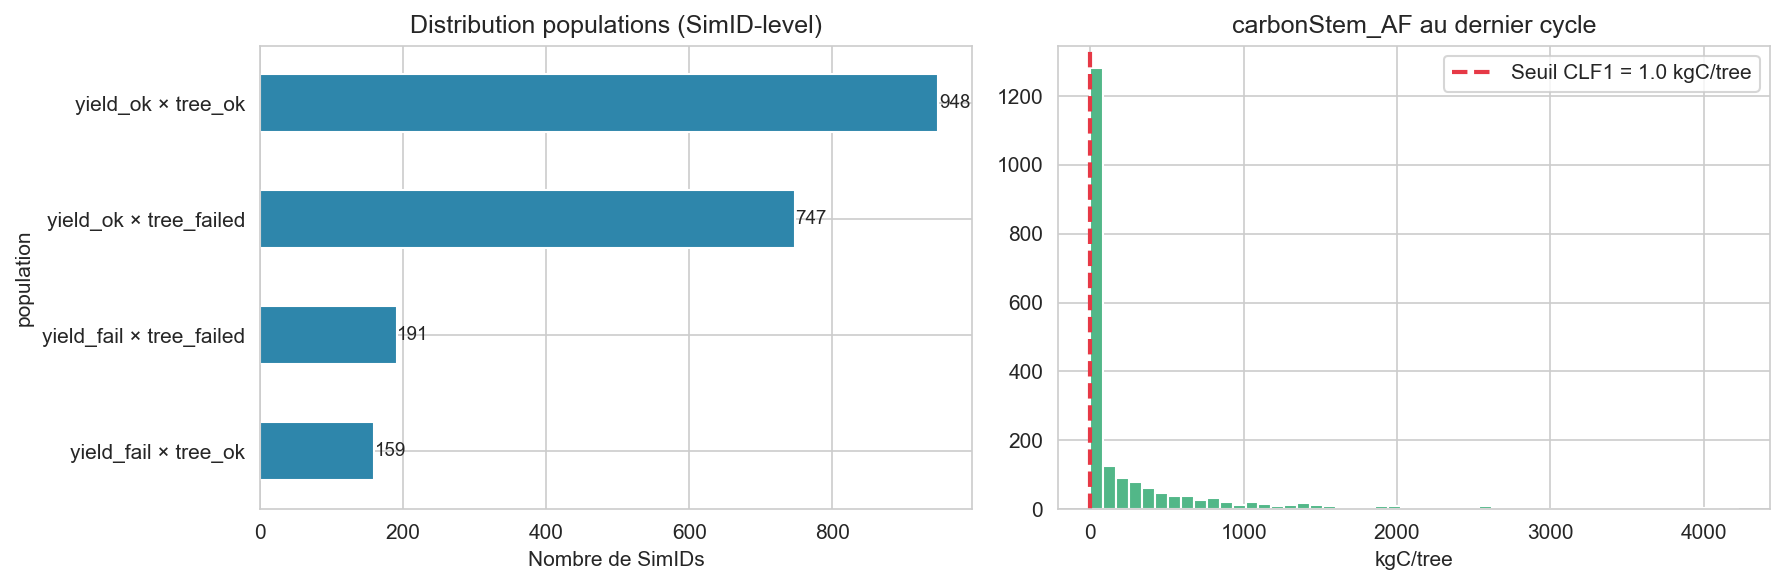

In [8]:
# ── 2b. Visualisation distribution populations ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot SimID-level
pop_counts.sort_values().plot.barh(ax=axes[0], color="#2E86AB")
axes[0].set_title("Distribution populations (SimID-level)")
axes[0].set_xlabel("Nombre de SimIDs")
for i, v in enumerate(pop_counts.sort_values()):
    axes[0].text(v + 1, i, f"{v}", va="center", fontsize=9)

# Distribution carbonStem_AF à la dernière année (CLF1 signal)
last_year = df_all_pops.sort_values(["SimID", "Harvest_Year_Absolute"]).groupby("SimID").last()
last_year["carbonStem_AF"].hist(
    ax=axes[1], bins=50, color="#52B788", edgecolor="white"
)
axes[1].axvline(TREE_FAIL_THRESHOLD, color="#E63946", linestyle="--", linewidth=2,
                label=f"Seuil CLF1 = {TREE_FAIL_THRESHOLD} kgC/tree")
axes[1].set_title("carbonStem_AF au dernier cycle")
axes[1].set_xlabel("kgC/tree")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# ── 2c. Filtre vers population nominale (entraînement méta-modèle) ────────────
df_nominal, _ = filter_population(
    df,
    population=NOMINAL_POPULATION,
    tree_fail_threshold=TREE_FAIL_THRESHOLD,
    yield_fail_threshold=YIELD_FAIL_THRESHOLD,
    yield_fail_rate=YIELD_FAIL_RATE,
    verbose=True,
)

n_sims_nominal = df_nominal["SimID"].nunique()
log.info(
    "Population nominale : %d lignes | %d SimIDs",
    len(df_nominal), n_sims_nominal,
)

# Validation : aucune valeur aberrante dans carbonStem_AF après filtrage
cs_last = (
    df_nominal
    .sort_values(["SimID", "Harvest_Year_Absolute"])
    .groupby("SimID")["carbonStem_AF"]
    .last()
)
assert (cs_last >= TREE_FAIL_THRESHOLD).all(), (
    f"Des SimIDs tree_failed présents dans la population nominale ! "
    f"Min carbonStem_AF = {cs_last.min():.3f}"
)
log.info(
    "✅ Tous les SimIDs nominaux ont carbonStem_AF >= %.1f kgC/tree au dernier cycle",
    TREE_FAIL_THRESHOLD,
)

14:08:58 [INFO] data.preparation — Population distribution:
14:08:58 [INFO] data.preparation —   yield_ok × tree_ok                  :  948  (46.4%)
14:08:58 [INFO] data.preparation —   yield_ok × tree_failed              :  747  (36.5%)
14:08:58 [INFO] data.preparation —   yield_fail × tree_ok                :  159  ( 7.8%)
14:08:58 [INFO] data.preparation —   yield_fail × tree_failed            :  191  ( 9.3%)
14:08:58 [INFO] data.preparation — Filtered to 'yield_ok × tree_ok' : 37920 rows | 948 SimIDs  (46.4% of total rows)
14:08:58 [INFO] metaisafe.notebook — Population nominale : 37920 lignes | 948 SimIDs
14:08:58 [INFO] metaisafe.notebook — ✅ Tous les SimIDs nominaux ont carbonStem_AF >= 1.0 kgC/tree au dernier cycle


---
## [3] STEP 3 — Split train/test + CV

**Ce qu'on valide ici :**
- Intégrité SimID : aucun SimID partagé entre train et test
- Stratification par type de rotation : proportions préservées
- Groupes CV alignés avec X_train
- Aucun leakage temporel possible

In [10]:
# ── 3a. Aperçu des types de rotation avant split ─────────────────────────────
rot_summary = summarise_rotations(df_nominal)
log.info("Types de rotation dans la population nominale :")
display(rot_summary)

14:08:59 [INFO] metaisafe.notebook — Types de rotation dans la population nominale :


,rotation_signature,n_sims,pct_sims
0,maize,563,59.388186
1,wheat,385,40.611814


In [11]:
# ── 3b. Split stratifié par rotation ─────────────────────────────────────────
train_df, test_df, train_idx, test_idx = stratified_split_by_rotation(
    df_nominal,
    test_size=0.20,
    random_state=RANDOM_STATE,
    verbose=True,
)

# Validation anti-leakage : aucun SimID partagé
train_sims = set(train_df["SimID"].unique())
test_sims  = set(test_df["SimID"].unique())
overlap    = train_sims & test_sims
assert not overlap, f"LEAKAGE : {len(overlap)} SimIDs dans train ET test : {list(overlap)[:5]}"
log.info("✅ Aucun SimID partagé entre train et test")

# Validation tailles
total_sims = df_nominal["SimID"].nunique()
log.info(
    "Split — Train: %d SimIDs (%d rows)  |  Test: %d SimIDs (%d rows)",
    len(train_sims), len(train_df),
    len(test_sims),  len(test_df),
)
assert abs(len(test_sims) / total_sims - 0.20) < 0.05, "Ratio train/test trop éloigné de 80/20"
log.info("✅ Ratio train/test correct")

14:08:59 [INFO] data.splitter — Rotation types detected:
rotation_signature  n_sims  pct_sims
             maize     563 59.388186
             wheat     385 40.611814

14:08:59 [INFO] data.splitter — 
14:08:59 [INFO] data.splitter — STRATIFIED TRAIN/TEST SPLIT BY ROTATION
14:08:59 [INFO] data.splitter — ============================================================
14:08:59 [INFO] data.splitter — Total     : 948 sims  |  37920 rows
14:08:59 [INFO] data.splitter — Train     : 759 sims  |  30360 rows  (80.1%)
14:08:59 [INFO] data.splitter — Test      : 189 sims  |  7560 rows  (19.9%)
14:08:59 [INFO] data.splitter — ============================================================

14:08:59 [INFO] metaisafe.notebook — ✅ Aucun SimID partagé entre train et test
14:08:59 [INFO] metaisafe.notebook — Split — Train: 759 SimIDs (30360 rows)  |  Test: 189 SimIDs (7560 rows)
14:08:59 [INFO] metaisafe.notebook — ✅ Ratio train/test correct


In [12]:
# ── 3c. Vérification stratification ──────────────────────────────────────────
from data.splitter import get_rotation_signature

sig_train = get_rotation_signature(train_df).value_counts(normalize=True) * 100
sig_test  = get_rotation_signature(test_df).value_counts(normalize=True) * 100

strat_check = pd.DataFrame({
    "train_%": sig_train,
    "test_%":  sig_test,
}).fillna(0).round(1)
strat_check["delta"] = (strat_check["train_%"] - strat_check["test_%"]).abs().round(1)

display(strat_check)

MAX_STRAT_DELTA = 10.0  # tolérance en points de %
if (strat_check["delta"] > MAX_STRAT_DELTA).any():
    log.warning("⚠ Déséquilibre de stratification > %.0f%% sur certains types", MAX_STRAT_DELTA)
else:
    log.info("✅ Stratification correcte (Δ max < %.0f%%)", MAX_STRAT_DELTA)

,train_%,test_%,delta
rotation_signature,,,
maize,59.4,59.3,0.1
wheat,40.6,40.7,0.1


14:08:59 [INFO] metaisafe.notebook — ✅ Stratification correcte (Δ max < 10%)


In [13]:
# ── 3d. Groupes CV ────────────────────────────────────────────────────────────
groups = build_cv_groups(train_df)
cv     = make_group_kfold(n_splits=5)

# Validation alignement : groupes alignés avec train_df
assert len(groups) == len(train_df), "Groupes CV non alignés avec train_df"
assert groups.nunique() == len(train_sims), "Nombre de groupes ≠ nombre de SimIDs train"
log.info("✅ Groupes CV : %d SimIDs, %d folds", groups.nunique(), cv.n_splits)

# Vérification anti-leakage dans chaque fold
X_dummy = train_df[["SimID"]].reset_index(drop=True)
y_dummy = pd.Series(0, index=range(len(train_df)))
for fold_i, (tr_idx, val_idx) in enumerate(cv.split(X_dummy, y_dummy, groups=groups)):
    sims_tr  = set(groups.iloc[tr_idx])
    sims_val = set(groups.iloc[val_idx])
    assert not (sims_tr & sims_val), f"Fold {fold_i+1} : leakage SimID détecté !"
log.info("✅ Aucun leakage SimID dans les 5 folds CV")

14:08:59 [INFO] metaisafe.notebook — ✅ Groupes CV : 759 SimIDs, 5 folds
14:08:59 [INFO] metaisafe.notebook — ✅ Aucun leakage SimID dans les 5 folds CV


---
## [4] STEP 4 — Encodage & winsorisation

**Ce qu'on valide ici :**
- Encodage catégoriel LightGBM (dtype `category`) sur train puis appliqué sur test
- Winsorisation fit sur train uniquement, appliquée sur test avec les bounds de train
- Aucune modification des features non-cibles
- Construction des matrices X/y pour train et test

In [14]:
# ── 4a. Encodage catégoriel ───────────────────────────────────────────────────
# Fit sur train
train_df, encoders = encode_categoricals(
    train_df,
    features=ACTIVE_FEATURES_B2,
    fit=True,
    method="lightgbm",
    verbose=True,
)
# Apply sur test (bounds du train)
test_df, _ = encode_categoricals(
    test_df,
    features=ACTIVE_FEATURES_B2,
    fit=False,
    encoders=encoders,
    method="lightgbm",
    verbose=True,
)

# Validation : colonnes catégorielles bien castées
from column_taxonomy import CATEGORICAL_FEATURES_B2
for col in CATEGORICAL_FEATURES_B2:
    if col in train_df.columns:
        assert train_df[col].dtype.name == "category", f"{col} n'est pas category dans train"
        assert test_df[col].dtype.name  == "category", f"{col} n'est pas category dans test"
log.info("✅ Encodage catégoriel LightGBM validé")

14:08:59 [INFO] data.loader — 🏷️  Encoding 2 categorical features (method='lightgbm', fit=True)
14:08:59 [INFO] data.loader —    • main_crop                 → category (2 levels)
14:08:59 [INFO] data.loader —    • w_type                    → category (2 levels)
14:08:59 [INFO] data.loader — 🏷️  Encoding 2 categorical features (method='lightgbm', fit=False)
14:08:59 [INFO] data.loader —    • main_crop                 → category (2 levels)
14:08:59 [INFO] data.loader —    • w_type                    → category (2 levels)
14:08:59 [INFO] metaisafe.notebook — ✅ Encodage catégoriel LightGBM validé


In [15]:
# ── 4b. Winsorisation ─────────────────────────────────────────────────────────
# Fit sur train
train_wins, win_bounds = apply_winsorization(
    train_df,
    quantiles=(0.01, 0.99),
    fit=True,
    verbose=True,
)
# Apply sur test avec les bounds du train
test_wins, _ = apply_winsorization(
    test_df,
    quantiles=(0.01, 0.99),
    fit=False,
    bounds=win_bounds,
    verbose=True,
)

log.info("Bounds winsorisation (5 premières colonnes) :")
for col, (lo, hi) in list(win_bounds.items())[:5]:
    log.info("  %-25s  [%.3f, %.3f]", col, lo, hi)

# Validation : pas de valeurs hors bounds dans train après winsorisation
for col, (lo, hi) in win_bounds.items():
    if col in train_wins.columns:
        assert train_wins[col].min() >= lo - 1e-9, f"{col} min < lo après winsorisation"
        assert train_wins[col].max() <= hi + 1e-9, f"{col} max > hi après winsorisation"
log.info("✅ Winsorisation validée — aucune valeur hors bounds dans train")

14:08:59 [INFO] data.preprocessing — Winsorisation [0.010, 0.990]  (fit=True)
14:08:59 [INFO] data.preprocessing —    • yield_AF                        [0.000, 12.493]  — 304 values clipped
14:08:59 [INFO] data.preprocessing —    • yield_TA                        [0.000, 12.520]  — 0 values clipped
14:08:59 [INFO] data.preprocessing —    • biomass_AF                      [0.029, 33.411]  — 608 values clipped
14:08:59 [INFO] data.preprocessing —    • biomass_TA                      [0.022, 32.159]  — 608 values clipped
14:08:59 [INFO] data.preprocessing —    • grainBiomass_AF                 [0.000, 12.493]  — 608 values clipped
14:08:59 [INFO] data.preprocessing —    • grainBiomass_TA                 [0.000, 12.520]  — 0 values clipped
14:08:59 [INFO] data.preprocessing —    • carbonStem_AF                   [0.008, 2082.392]  — 304 values clipped
14:08:59 [INFO] data.preprocessing —    • carbonStem_TF                   [0.008, 101.444]  — 304 values clipped
14:08:59 [INFO] data.prepro

In [16]:
# ── 4c. Construction X/y ──────────────────────────────────────────────────────
X_train, y_train_all, used_features, used_targets = build_dataset(
    train_wins,
    features=ACTIVE_FEATURES_B2,
    targets=STOCK_TARGETS_MINIMAL,
    verbose=True,
)
X_test, y_test_all, _, _ = build_dataset(
    test_wins,
    features=ACTIVE_FEATURES_B2,
    targets=STOCK_TARGETS_MINIMAL,
    verbose=True,
)

# Validation dimensions et alignement
assert X_train.shape[1] == X_test.shape[1], "Nombre de features différent entre train et test"
assert list(X_train.columns) == list(X_test.columns), "Ordre des features différent"
assert X_train.shape[0] == len(train_wins), "Nombre de lignes X_train ≠ train_wins"

log.info(
    "X_train : %d × %d  |  X_test : %d × %d",
    *X_train.shape, *X_test.shape
)
log.info("Features utilisées : %s", used_features)
log.info("Targets  utilisées : %s", used_targets)
log.info("✅ Matrices X/y construites et validées")

14:08:59 [INFO] data.loader — 📐 Dataset built — X: 30360 rows × 12 features | y: 30360 rows × 4 targets
14:08:59 [INFO] data.loader — 📐 Dataset built — X: 7560 rows × 12 features | y: 7560 rows × 4 targets
14:08:59 [INFO] metaisafe.notebook — X_train : 30360 × 12  |  X_test : 7560 × 12
14:08:59 [INFO] metaisafe.notebook — Features utilisées : ['Harvest_Year_Absolute', 'latitude', 'longitude', 'plotWidth', 'plotHeight', 'soilDepth', 'sand', 'clay', 'stone', 'waterTable', 'main_crop', 'w_type']
14:08:59 [INFO] metaisafe.notebook — Targets  utilisées : ['yield_AF', 'yield_TA', 'carbonStem_AF', 'carbonStem_TF']
14:08:59 [INFO] metaisafe.notebook — ✅ Matrices X/y construites et validées


---
## [5a] STEP 5a — Classifieurs CLF1 / CLF2

**Ce qu'on valide ici :**
- Construction des labels CLF1 et CLF2 sur le dataset COMPLET (toutes populations)
- Entraînement CLF1 (tree_fail) et CLF2 (yield_fail)
- Métriques de classification : accuracy, F1, ROC-AUC
- Activation éventuelle de la règle géographique fallback pour CLF2
- Persistance sur disque et rechargement

**Valeurs de référence B2 :**
| Classifieur | Accuracy | Note |
|---|---|---|
| CLF1 | ~66.7% | Frontière diffuse dans l'espace textural |
| CLF2 | ~91.5% | Frontière géographique nette |

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# [5a] STEP 5a — Cascade Classifiers CLF1 / CLF2
# ══════════════════════════════════════════════════════════════════════════════

from data.splitter import split_by_simid
from modeling.classifiers import (
    build_tree_fail_classifier, build_yield_fail_classifier,
    build_classifier_features, build_tree_fail_labels, build_yield_fail_labels,
    apply_geographic_rule, evaluate_classifier,
    save_classifiers, CLF1_FEATURES, CLF2_FEATURES,
)
from modeling.trainer import train_classifier

# ── 5a-0. Split du dataset complet pour les classifieurs ─────────────────────
# Les classifieurs sont entraînés sur df COMPLET (toutes populations)
# → ils ont besoin de voir les cas de failure pour apprendre à les distinguer.
# split_by_simid garantit qu'aucun SimID n'apparaît dans les deux partitions.

df_clf_train, df_clf_test, _, _ = split_by_simid(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    verbose=True,
)

log.info(
    "CLF split — train: %d SimIDs | test: %d SimIDs",
    df_clf_train["SimID"].nunique(),
    df_clf_test["SimID"].nunique(),
)

# ── 5a-i. CLF1 — Tree failure ─────────────────────────────────────────────────

clf1_model, _, _ = build_tree_fail_classifier(df, verbose=True)

X_clf1_train = build_classifier_features(df_clf_train, CLF1_FEATURES)
X_clf1_test  = build_classifier_features(df_clf_test,  CLF1_FEATURES)
y_clf1_train = build_tree_fail_labels(df_clf_train)
y_clf1_test  = build_tree_fail_labels(df_clf_test)

# Alignement sur SimIDs communs (sécurité)
for X, y in [(X_clf1_train, y_clf1_train), (X_clf1_test, y_clf1_test)]:
    common = X.index.intersection(y.index)
    X = X.loc[common]; y = y.loc[common]

# Réassignation propre après alignement
common_train  = X_clf1_train.index.intersection(y_clf1_train.index)
common_test   = X_clf1_test.index.intersection(y_clf1_test.index)
X_clf1_train  = X_clf1_train.loc[common_train]
y_clf1_train  = y_clf1_train.loc[common_train]
X_clf1_test   = X_clf1_test.loc[common_test]
y_clf1_test   = y_clf1_test.loc[common_test]

log.info(
    "CLF1 — train: %d SimIDs (%.1f%% failed) | test: %d SimIDs (%.1f%% failed)",
    len(y_clf1_train), 100.0 * y_clf1_train.mean(),
    len(y_clf1_test),  100.0 * y_clf1_test.mean(),
)

clf1_fitted, clf1_metrics = train_classifier(
    clf1_model,
    X_clf1_train, y_clf1_train,
    X_clf1_test,  y_clf1_test,
    verbose=True,
)

y_clf1_pred  = clf1_fitted.predict(X_clf1_test)
y_clf1_proba = clf1_fitted.predict_proba(X_clf1_test)[:, 1]
clf1_eval    = evaluate_classifier(
    y_clf1_test, y_clf1_pred, y_clf1_proba,
    classifier_name="CLF1 — Tree Failure",
    verbose=True,
)

if clf1_eval["accuracy"] < 0.55:
    log.warning("⚠ CLF1 accuracy < 55%% — vérifier les seuils et les features")
else:
    log.info("✅ CLF1 accuracy : %.1f%%", clf1_eval["accuracy"] * 100)


# ── 5a-ii. CLF2 — Yield failure ───────────────────────────────────────────────

clf2_model, _, _ = build_yield_fail_classifier(df, verbose=True)

X_clf2_train = build_classifier_features(df_clf_train, CLF2_FEATURES)
X_clf2_test  = build_classifier_features(df_clf_test,  CLF2_FEATURES)
y_clf2_train = build_yield_fail_labels(df_clf_train)
y_clf2_test  = build_yield_fail_labels(df_clf_test)

# Alignement sur SimIDs communs
common_train  = X_clf2_train.index.intersection(y_clf2_train.index)
common_test   = X_clf2_test.index.intersection(y_clf2_test.index)
X_clf2_train  = X_clf2_train.loc[common_train]
y_clf2_train  = y_clf2_train.loc[common_train]
X_clf2_test   = X_clf2_test.loc[common_test]
y_clf2_test   = y_clf2_test.loc[common_test]

log.info(
    "CLF2 — train: %d SimIDs (%.1f%% failed) | test: %d SimIDs (%.1f%% failed)",
    len(y_clf2_train), 100.0 * y_clf2_train.mean(),
    len(y_clf2_test),  100.0 * y_clf2_test.mean(),
)

if clf2_model is None:
    # Fallback géographique — minority class insuffisante pour LightGBM
    y_clf2_pred = apply_geographic_rule(X_clf2_test)
    clf2_eval   = evaluate_classifier(
        y_clf2_test, y_clf2_pred,
        classifier_name="CLF2 — Yield Failure (geographic rule)",
        verbose=True,
    )
    clf2_fitted  = None
    clf2_metrics = {"rule": "geographic_fallback"}
    log.info("ℹ CLF2 : fallback géographique utilisé")
else:
    clf2_fitted, clf2_metrics = train_classifier(
        clf2_model,
        X_clf2_train, y_clf2_train,
        X_clf2_test,  y_clf2_test,
        verbose=True,
    )
    y_clf2_pred  = clf2_fitted.predict(X_clf2_test)
    y_clf2_proba = clf2_fitted.predict_proba(X_clf2_test)[:, 1]
    clf2_eval    = evaluate_classifier(
        y_clf2_test, y_clf2_pred, y_clf2_proba,
        classifier_name="CLF2 — Yield Failure",
        verbose=True,
    )

if clf2_eval.get("accuracy", 1.0) < 0.80:
    log.warning("⚠ CLF2 accuracy < 80%% — vérifier les seuils géographiques")
else:
    log.info("✅ CLF2 accuracy : %.1f%%", clf2_eval.get("accuracy", 1.0) * 100)


# threshold_clf2 = 0.35
# log.info("--- Adjusted CLF2 ---")
# y_clf2_pred_adj = (y_clf2_proba >= threshold_clf2).astype(int)
# clf2_eval_adj = evaluate_classifier(
#     y_clf2_test, y_clf2_pred_adj, y_clf2_proba,
#     classifier_name="CLF2 — Adjusted thsd: 0.35",
#     verbose=True,
# )
# log.info("✅ CLF2 adj accuracy : %.1f%%", clf2_eval_adj.get("accuracy", 1.0) * 100)

# ── 5a-iii. Sauvegarde ────────────────────────────────────────────────────────

path_clf1, path_clf2 = save_classifiers(
    clf1_fitted,
    clf2_fitted,
    campaign,
    clf1_meta={
        "accuracy_test": clf1_eval["accuracy"],
        "f1_test":       clf1_eval["f1"],
        "roc_auc_test":  clf1_eval.get("roc_auc", None),
        "n_train":       len(y_clf1_train),
        "n_test":        len(y_clf1_test),
    },
    clf2_meta={
        "accuracy_test": clf2_eval.get("accuracy"),
        "f1_test":       clf2_eval.get("f1"),
        "roc_auc_test":  clf2_eval.get("roc_auc"),
        "n_train":       len(y_clf2_train),
        "n_test":        len(y_clf2_test),
    } if clf2_fitted is not None else None,
)

log.info("✅ CLF1 saved : %s", path_clf1)
log.info("✅ CLF2 saved : %s", path_clf2)

14:08:59 [INFO] data.splitter — 
14:08:59 [INFO] data.splitter — TRAIN/TEST SPLIT BY SimID
14:08:59 [INFO] data.splitter — ============================================================
14:08:59 [INFO] data.splitter — Total     : 2045 sims  |  81800 rows
14:08:59 [INFO] data.splitter — Train     : 1636 sims  |  65440 rows  (80.0%)
14:08:59 [INFO] data.splitter — Test      : 409 sims  |  16360 rows  (20.0%)
14:08:59 [INFO] data.splitter — ============================================================

14:08:59 [INFO] metaisafe.notebook — CLF split — train: 1636 SimIDs | test: 409 SimIDs
14:08:59 [INFO] modeling.classifiers — ============================================================
14:08:59 [INFO] modeling.classifiers — CLF1 — Tree Failure Classifier
14:08:59 [INFO] modeling.classifiers — ============================================================
14:08:59 [INFO] modeling.classifiers — Features: ['clay', 'sand', 'stone', 'latitude', 'longitude', 'plotHeight', 'plotWidth', 'soilDepth', '

In [18]:
# Sanity check : combien de SimIDs nominaux sont mal routés ?
from modeling.classifiers import predict_routing, build_classifier_features, CLF1_FEATURES, CLF2_FEATURES

X_nominal_clf = build_classifier_features(df_nominal, CLF1_FEATURES + [c for c in CLF2_FEATURES if c not in CLF1_FEATURES])
routing = predict_routing(X_nominal_clf, clf1_fitted, clf2_fitted)
n_mismatch = (routing["population"] != NOMINAL_POPULATION).sum()
log.info(
    "Routing check — SimIDs nominaux mal routés : %d / %d (%.1f%%)",
    n_mismatch, len(routing), 100.0 * n_mismatch / len(routing),
)

14:09:01 [INFO] modeling.classifiers — Classifier feature matrix: 948 SimIDs × 10 features
14:09:01 [INFO] metaisafe.notebook — Routing check — SimIDs nominaux mal routés : 55 / 948 (5.8%)


---
## [5b] STEP 5b — Stage 1 : carbonStem_AF & carbonStem_TF

**Ce qu'on valide ici :**
- CV GroupKFold 5 folds sur chaque target stage 1
- Entraînement final sur train complet
- R² test ≥ 0.85 (seuil de qualité B2)
- Prédictions stage 1 construites pour injection dans stage 2

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# [5b] STEP 5b — Stage 1 : carbonStem_AF, carbonStem_TF
# ══════════════════════════════════════════════════════════════════════════════

from modeling.models   import build_lgb, get_feature_importances
from modeling.trainer  import cross_validate, train_final_model
from modeling.evaluator import compute_metrics, plot_pred_vs_obs, plot_residuals, plot_feature_importances
from utils.io_utils    import save_model, save_metrics, save_cv_results, save_predictions, save_feature_importances

# ── 5b-0. Préparation dataset nominal ────────────────────────────────────────
# Les régresseurs stage 1 sont entraînés sur df_nominal uniquement
# (yield_ok × tree_ok) — les cas tree_failed ont carbonStem ~ 0
# et contamineraient le modèle.

# Split train/test sur df_nominal (déjà effectué en [3] → train_df / test_df)
# On vérifie que train_df et test_df sont bien issus de df_nominal
assert set(train_df["SimID"].unique()).isdisjoint(set(test_df["SimID"].unique())), \
    "Leakage détecté : SimIDs communs entre train et test !"

log.info(
    "Stage 1 dataset — train: %d rows (%d SimIDs) | test: %d rows (%d SimIDs)",
    len(train_df), train_df["SimID"].nunique(),
    len(test_df),  test_df["SimID"].nunique(),
)

# Features et groupes CV
cat_feats_b2 = [c for c in CATEGORICAL_FEATURES_B2 if c in train_df.columns]
groups_train = build_cv_groups(train_df)
cv           = make_group_kfold(n_splits=CV_N_FOLDS)

# Stockage des prédictions stage 1 (injectées en stage 2)
stage1_train_preds = pd.DataFrame(index=train_df.index)
stage1_test_preds  = pd.DataFrame(index=test_df.index)
stage1_models      = {}
stage1_metrics     = {}

14:09:01 [INFO] metaisafe.notebook — Stage 1 dataset — train: 30360 rows (759 SimIDs) | test: 7560 rows (189 SimIDs)


In [22]:
MIN_CARBON = 1.0      # ← seuil physique minimum (kgC/tree)
USE_LOG1P  = True     # ← transformation log1p

for target in SEQUENTIAL_TARGETS_STAGE1:

    log.info("\n%s", "=" * 60)
    log.info("STAGE 1 — Target : %s", target)
    log.info("%s", "=" * 60)

    # ── Filtre juvénile + log1p pour targets carbonStem ──────────────────

    # Filtre : exclure rows où la cible est sous le seuil juvénile
    train_df_t = train_df[train_df[target] >= MIN_CARBON].copy()
    test_df_t  = test_df[test_df[target]  >= MIN_CARBON].copy()

    log.info(
        "Filtre carbonStem >= %.1f — train: %d→%d rows | test: %d→%d rows",
        MIN_CARBON,
        len(train_df), len(train_df_t),
        len(test_df),  len(test_df_t),
    )

    # Groupes CV recalculés sur le dataset filtré
    groups_train_t = build_cv_groups(train_df_t)

    # Extraction X, y
    X_train, y_train_s, used_feats, _ = build_dataset(
        train_df_t,
        features=ACTIVE_FEATURES_B2,
        targets=[target],
        verbose=False,
    )
    X_test, y_test_s, _, _ = build_dataset(
        test_df_t,
        features=ACTIVE_FEATURES_B2,
        targets=[target],
        verbose=False,
    )
    y_train_s = y_train_s[target]
    y_test_s  = y_test_s[target]

    # ── Transformation log1p ──────────────────────────────────────────────
    if USE_LOG1P:
        y_train_log = np.log1p(y_train_s)
        y_test_log  = np.log1p(y_test_s)
        log.info(
            "log1p applied — y_train : [%.2f, %.2f] → [%.2f, %.2f]",
            y_train_s.min(), y_train_s.max(),
            y_train_log.min(), y_train_log.max(),
        )
    else:
        y_train_log = y_train_s
        y_test_log  = y_test_s

    # Sanity check
    assert y_train_log.isna().sum() == 0, f"NaN dans y_train pour {target}"
    assert y_test_log.isna().sum()  == 0, f"NaN dans y_test pour {target}"

    # Construction modèle
    model = build_lgb(categorical_feature=cat_feats_b2)

    # Cross-validation (sur espace log)
    cv_results = cross_validate(
        model, X_train, y_train_log,
        groups=groups_train_t,   # ← groupes recalculés sur df filtré
        cv=cv,
        verbose=True,
    )

    # Entraînement final (sur espace log)
    model_fitted, _ = train_final_model(
        model, X_train, y_train_log,
        X_test, y_test_log,
        verbose=True,
    )

    # ── Prédictions et back-transform ─────────────────────────────────────
    y_train_pred_log = model_fitted.predict(X_train)
    y_test_pred_log  = model_fitted.predict(X_test)

    if USE_LOG1P:
        y_train_pred = np.expm1(y_train_pred_log)
        y_test_pred  = np.expm1(y_test_pred_log)
        # Clip physique : carbonStem ne peut pas être négatif
        y_train_pred = np.clip(y_train_pred, 0, None)
        y_test_pred  = np.clip(y_test_pred,  0, None)
    else:
        y_train_pred = y_train_pred_log
        y_test_pred  = y_test_pred_log

    # ── Métriques dans l'espace original (kgC/tree) ───────────────────────
    metrics_train = compute_metrics(y_train_s.values, y_train_pred, prefix="train_")
    metrics_test  = compute_metrics(y_test_s.values,  y_test_pred,  prefix="test_")

    # Métriques log (pour comparer CV et test de façon cohérente)
    metrics_test_log = compute_metrics(
        y_test_log.values, y_test_pred_log, prefix="test_log_"
    )
    all_metrics = {**metrics_train, **metrics_test, **metrics_test_log, **cv_results}

    log.info(
        "%s — CV R²(log)=%.3f ± %.3f | Test R²(orig)=%.3f | RMSE(orig)=%.3f | Bias=%.3f",
        target,
        cv_results["mean_r2_val"],
        cv_results["std_r2_val"],
        metrics_test["test_r2"],
        metrics_test["test_rmse"],
        metrics_test["test_bias"],
    )

    # ── Stockage pour stage 2 — prédictions sur datasets COMPLETS ────────────────
    # On prédit sur train_df et test_df entiers (pas les versions filtrées)
    # pour que stage1_preds soit aligné avec X_train/X_test du stage 2.

    for df_full, store, name in [
        (train_df, stage1_train_preds, "train"),
        (test_df,  stage1_test_preds,  "test"),
    ]:
        X_full, _, _, _ = build_dataset(
            df_full, features=ACTIVE_FEATURES_B2,
            targets=[target], verbose=False,
        )
        preds_log = model_fitted.predict(X_full)
        preds     = np.clip(np.expm1(preds_log), 0, None) if USE_LOG1P else preds_log
        store[target] = preds
        log.info(
            "stage1_%s_preds[%s] — %d rows | min=%.2f | mean=%.2f | max=%.2f",
            name, target, len(preds), preds.min(), preds.mean(), preds.max(),
        )

14:12:16 [INFO] metaisafe.notebook — 
14:12:16 [INFO] metaisafe.notebook — STAGE 1 — Target : carbonStem_AF
14:12:16 [INFO] metaisafe.notebook — ============================================================
14:12:16 [INFO] metaisafe.notebook — Filtre carbonStem >= 1.0 — train: 30360→25259 rows | test: 7560→6190 rows
14:12:17 [INFO] metaisafe.notebook — log1p applied — y_train : [1.00, 4219.67] → [0.69, 8.35]


Cross-validation:   0%|          | 0/5 [00:00<?, ?it/s]

14:12:22 [INFO] modeling.trainer — 
14:12:22 [INFO] modeling.trainer — CROSS-VALIDATION RESULTS (5 folds)
14:12:22 [INFO] modeling.trainer — ============================================================
14:12:22 [INFO] modeling.trainer — Mean R² train : 0.995
14:12:22 [INFO] modeling.trainer — Mean R² val   : 0.406 ± 0.072
14:12:22 [INFO] modeling.trainer — Mean RMSE val : 1.420
14:12:22 [INFO] modeling.trainer — Mean MAE val  : 1.068
14:12:22 [INFO] modeling.trainer — ============================================================

14:12:22 [INFO] modeling.trainer — 🚀 Training final model on 25259 examples...
14:12:24 [INFO] modeling.trainer — 
14:12:24 [INFO] modeling.trainer — FINAL MODEL METRICS
14:12:24 [INFO] modeling.trainer — ============================================================
14:12:24 [INFO] modeling.trainer — R² train  : 0.993
14:12:24 [INFO] modeling.trainer — RMSE train: 0.154
14:12:24 [INFO] modeling.trainer — R² test   : 0.353
14:12:24 [INFO] modeling.trainer — RMSE 

Cross-validation:   0%|          | 0/5 [00:00<?, ?it/s]

14:12:30 [INFO] modeling.trainer — 
14:12:30 [INFO] modeling.trainer — CROSS-VALIDATION RESULTS (5 folds)
14:12:30 [INFO] modeling.trainer — ============================================================
14:12:30 [INFO] modeling.trainer — Mean R² train : 0.996
14:12:30 [INFO] modeling.trainer — Mean R² val   : 0.588 ± 0.022
14:12:30 [INFO] modeling.trainer — Mean RMSE val : 0.641
14:12:30 [INFO] modeling.trainer — Mean MAE val  : 0.489
14:12:30 [INFO] modeling.trainer — ============================================================

14:12:30 [INFO] modeling.trainer — 🚀 Training final model on 23146 examples...
14:12:32 [INFO] modeling.trainer — 
14:12:32 [INFO] modeling.trainer — FINAL MODEL METRICS
14:12:32 [INFO] modeling.trainer — ============================================================
14:12:32 [INFO] modeling.trainer — R² train  : 0.995
14:12:32 [INFO] modeling.trainer — RMSE train: 0.071
14:12:32 [INFO] modeling.trainer — R² test   : 0.550
14:12:32 [INFO] modeling.trainer — RMSE 

In [23]:
# ── Diagnostic : variance expliquée par les features vs SimID ────────────────
# Si la variance inter-SimID domine, le modèle ne peut pas généraliser.

from sklearn.metrics import r2_score

# R² d'un modèle naïf "moyenne par année" (baseline temporelle)
yearly_mean = train_df.groupby("Harvest_Year_Absolute")[target].mean()
y_test_baseline = test_df["Harvest_Year_Absolute"].map(yearly_mean)
r2_baseline = r2_score(
    test_df[target].fillna(0),
    y_test_baseline.fillna(0),
)
log.info("R² baseline (moyenne par année) : %.3f", r2_baseline)

# Variance décomposition
var_total     = train_df[target].var()
var_interSimID = train_df.groupby("SimID")[target].mean().var()
var_intraSimID = train_df.groupby("SimID")[target].var().mean()

log.info(
    "Variance totale    : %.1f\n"
    "Variance inter-SimID (entre simulations) : %.1f  (%.1f%%)\n"
    "Variance intra-SimID (dans une simulation) : %.1f  (%.1f%%)",
    var_total,
    var_interSimID, 100 * var_interSimID / var_total,
    var_intraSimID, 100 * var_intraSimID / var_total,
)

14:13:01 [INFO] metaisafe.notebook — R² baseline (moyenne par année) : 0.224
14:13:01 [INFO] metaisafe.notebook — Variance totale    : 498.9
Variance inter-SimID (entre simulations) : 249.9  (50.1%)
Variance intra-SimID (dans une simulation) : 255.7  (51.3%)


14:16:36 [INFO] metaisafe.notebook — rate_AF — mean=1.174 | std=0.308 | min=1.000 | p5=1.000 | p95=1.787 | max=4.480
14:16:36 [INFO] metaisafe.notebook — rate_TF — mean=1.088 | std=0.153 | min=1.000 | p5=1.001 | p95=1.335 | max=3.228


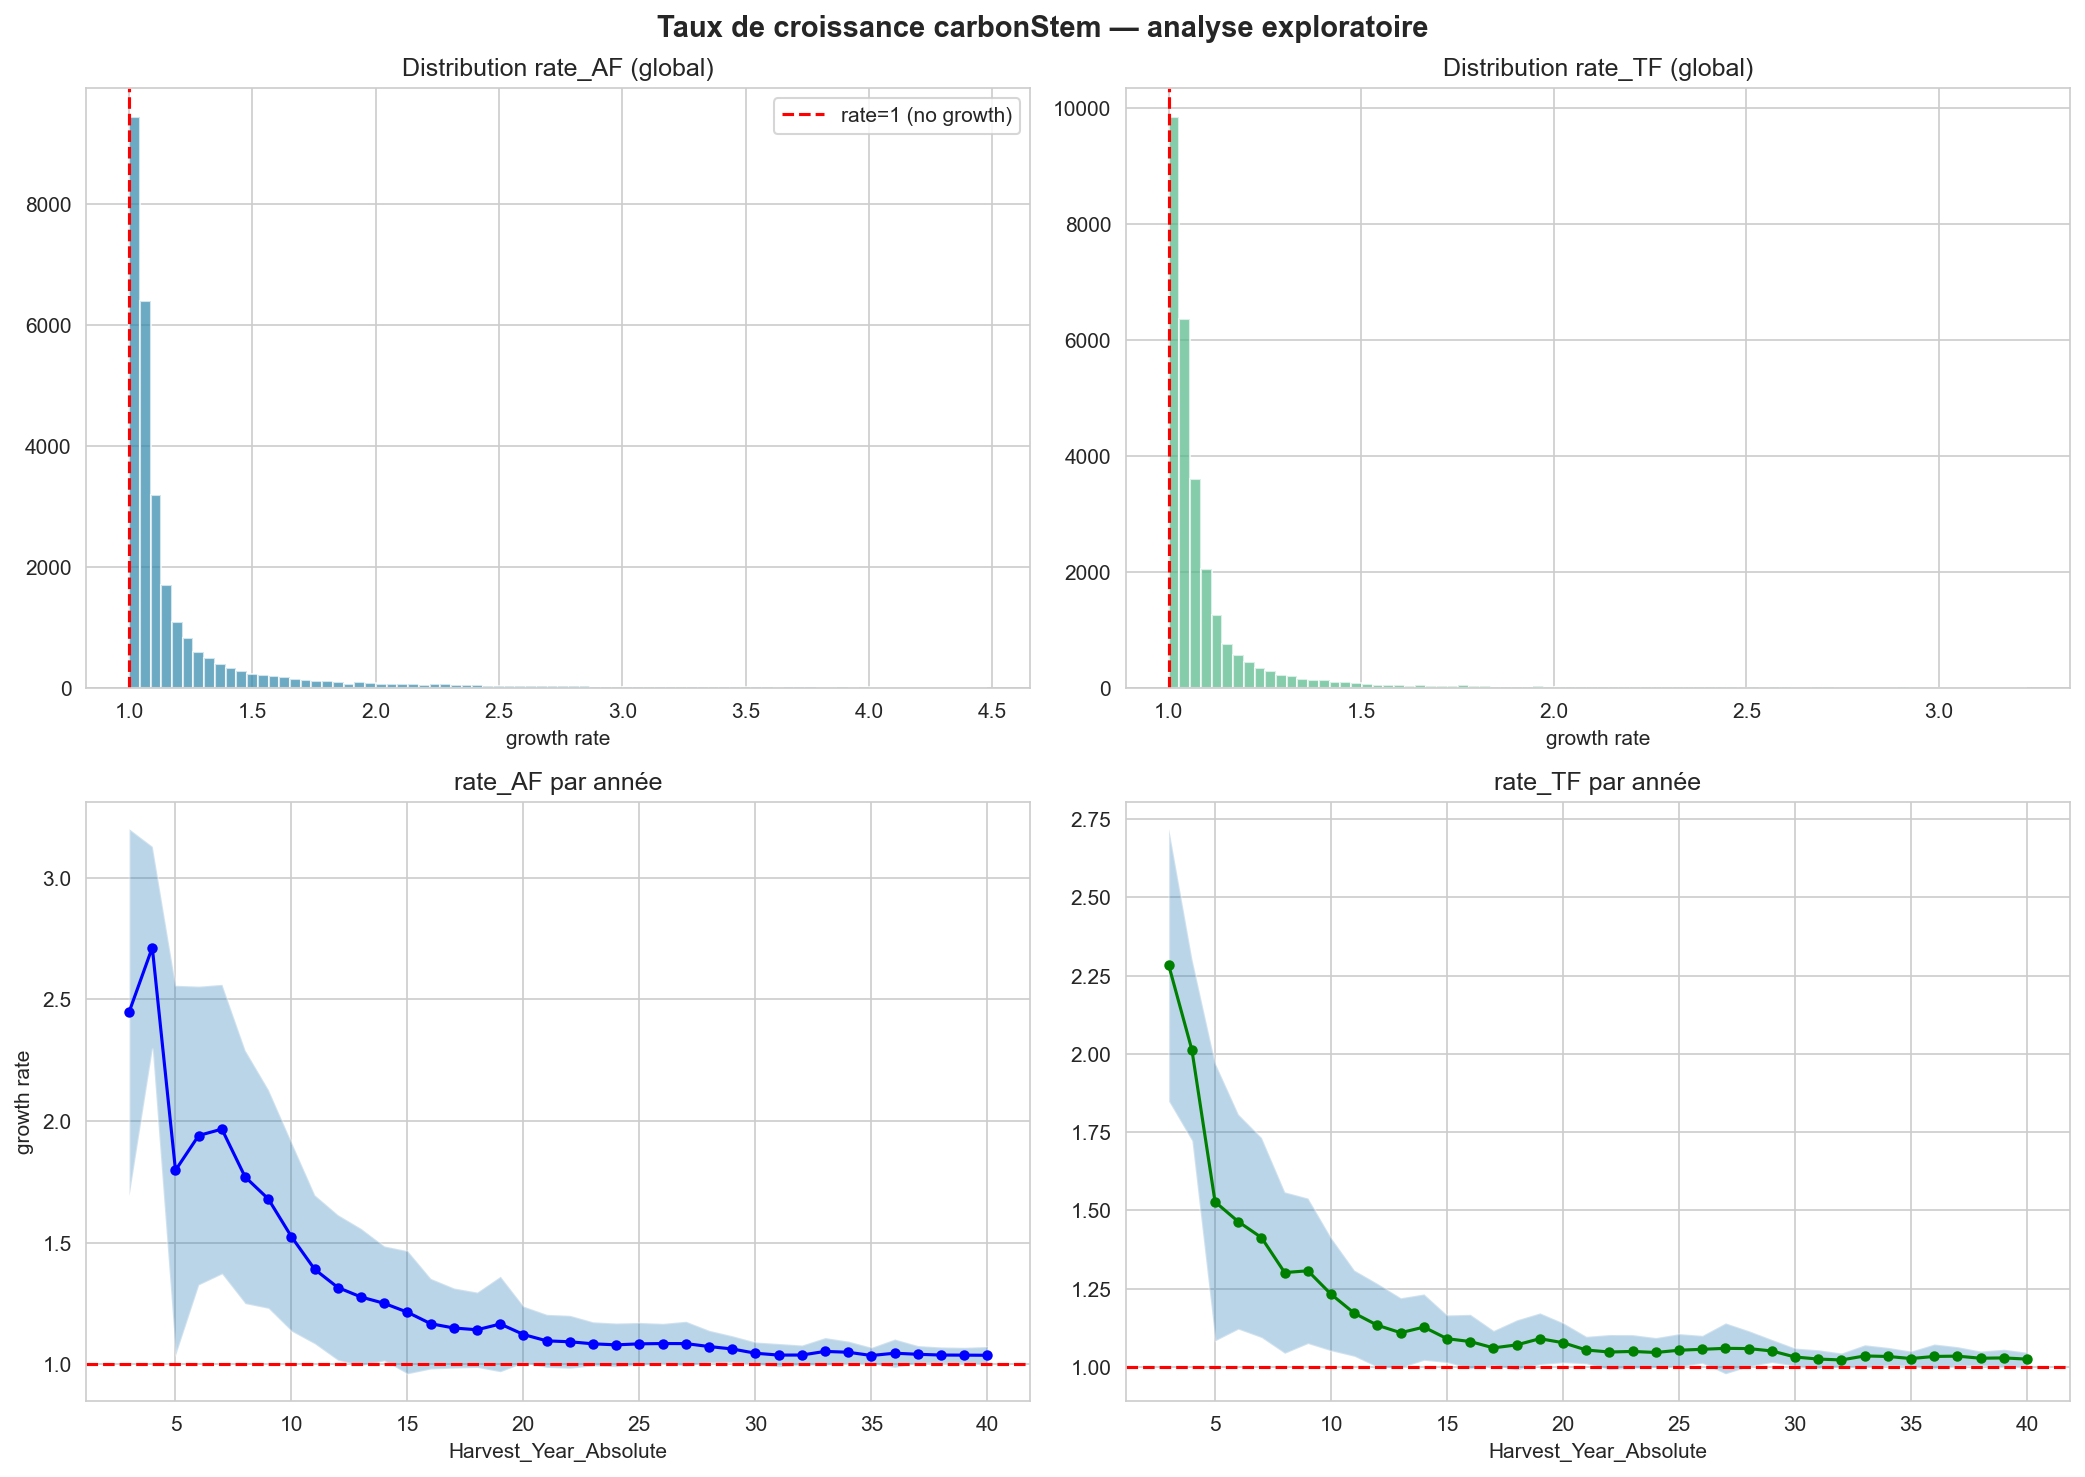

14:16:36 [INFO] metaisafe.notebook — 
Variance rate_AF :
  Totale          : 0.0949
  Inter-SimID     : 0.0053  (5.6%)
  Intra-SimID     : 0.0892  (94.0%)


In [24]:
# ── Diagnostic : distribution des taux de croissance ─────────────────────────

# Calcul des taux dans df_nominal
df_rates = df_nominal.copy().sort_values(["SimID", "Harvest_Year_Absolute"])

df_rates["carbonStem_AF_lag"] = df_rates.groupby("SimID")["carbonStem_AF"].shift(1)
df_rates["carbonStem_TF_lag"] = df_rates.groupby("SimID")["carbonStem_TF"].shift(1)

# Filtrer year > 1 et dénominateur > seuil
MIN_LAG = 1.0
df_rates = df_rates[
    (df_rates["Harvest_Year_Absolute"] > 1) &
    (df_rates["carbonStem_AF_lag"] > MIN_LAG) &
    (df_rates["carbonStem_TF_lag"] > MIN_LAG)
].copy()

df_rates["rate_AF"] = df_rates["carbonStem_AF"] / df_rates["carbonStem_AF_lag"]
df_rates["rate_TF"] = df_rates["carbonStem_TF"] / df_rates["carbonStem_TF_lag"]

# Stats de base
for col in ["rate_AF", "rate_TF"]:
    log.info(
        "%s — mean=%.3f | std=%.3f | min=%.3f | p5=%.3f | p95=%.3f | max=%.3f",
        col,
        df_rates[col].mean(),
        df_rates[col].std(),
        df_rates[col].min(),
        df_rates[col].quantile(0.05),
        df_rates[col].quantile(0.95),
        df_rates[col].max(),
    )

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution globale des taux
axes[0,0].hist(df_rates["rate_AF"].clip(0, 5), bins=80, color="#2E86AB", alpha=0.7)
axes[0,0].axvline(1.0, color="red", linestyle="--", label="rate=1 (no growth)")
axes[0,0].set_title("Distribution rate_AF (global)")
axes[0,0].set_xlabel("growth rate")
axes[0,0].legend()

axes[0,1].hist(df_rates["rate_TF"].clip(0, 5), bins=80, color="#52B788", alpha=0.7)
axes[0,1].axvline(1.0, color="red", linestyle="--")
axes[0,1].set_title("Distribution rate_TF (global)")
axes[0,1].set_xlabel("growth rate")

# Évolution du taux moyen par année
rate_by_year = df_rates.groupby("Harvest_Year_Absolute")[["rate_AF", "rate_TF"]].agg(["mean", "std"])

axes[1,0].plot(rate_by_year.index, rate_by_year["rate_AF"]["mean"], "b-o", ms=4, label="mean")
axes[1,0].fill_between(
    rate_by_year.index,
    rate_by_year["rate_AF"]["mean"] - rate_by_year["rate_AF"]["std"],
    rate_by_year["rate_AF"]["mean"] + rate_by_year["rate_AF"]["std"],
    alpha=0.3
)
axes[1,0].axhline(1.0, color="red", linestyle="--")
axes[1,0].set_title("rate_AF par année")
axes[1,0].set_xlabel("Harvest_Year_Absolute")
axes[1,0].set_ylabel("growth rate")

axes[1,1].plot(rate_by_year.index, rate_by_year["rate_TF"]["mean"], "g-o", ms=4)
axes[1,1].fill_between(
    rate_by_year.index,
    rate_by_year["rate_TF"]["mean"] - rate_by_year["rate_TF"]["std"],
    rate_by_year["rate_TF"]["mean"] + rate_by_year["rate_TF"]["std"],
    alpha=0.3
)
axes[1,1].axhline(1.0, color="red", linestyle="--")
axes[1,1].set_title("rate_TF par année")
axes[1,1].set_xlabel("Harvest_Year_Absolute")

plt.suptitle("Taux de croissance carbonStem — analyse exploratoire", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Variance décomposition sur les taux
var_total_rate    = df_rates["rate_AF"].var()
var_inter_rate    = df_rates.groupby("SimID")["rate_AF"].mean().var()
var_intra_rate    = df_rates.groupby("SimID")["rate_AF"].var().mean()

log.info(
    "\nVariance rate_AF :\n"
    "  Totale          : %.4f\n"
    "  Inter-SimID     : %.4f  (%.1f%%)\n"
    "  Intra-SimID     : %.4f  (%.1f%%)",
    var_total_rate,
    var_inter_rate, 100 * var_inter_rate / var_total_rate,
    var_intra_rate, 100 * var_intra_rate / var_total_rate,
)

In [28]:
# ── Diagnostic préalable : R² attendu sur stock final ────────────────────────

# Extraire une ligne par SimID : valeur à la dernière année disponible
df_final = (
    df_nominal
    .sort_values(["SimID", "Harvest_Year_Absolute"])
    .groupby("SimID")
    .last()
    .reset_index()
)

df_final, _ = encode_categoricals(df_final, features=ACTIVE_FEATURES_B2)

log.info(
    "Dataset SimID-level : %d SimIDs | carbonStem_AF_final — "
    "mean=%.1f | std=%.1f | min=%.1f | max=%.1f",
    len(df_final),
    df_final["carbonStem_AF"].mean(),
    df_final["carbonStem_AF"].std(),
    df_final["carbonStem_AF"].min(),
    df_final["carbonStem_AF"].max(),
)

# Split par SimID (déjà garanti — une ligne par SimID)
from sklearn.model_selection import train_test_split as sk_split
df_final_train, df_final_test = sk_split(
    df_final, test_size=0.2,
    random_state=RANDOM_STATE,
)

# Features statiques uniquement (pas de temporel)
static_feats = [f for f in ACTIVE_FEATURES_B2 if f != "Harvest_Year_Absolute"]

X_final_train = df_final_train[static_feats]
X_final_test  = df_final_test[static_feats]
y_final_train = np.log1p(df_final_train["carbonStem_AF"])
y_final_test  = np.log1p(df_final_test["carbonStem_AF"])

# Modèle rapide pour estimer le R² atteignable
from modeling.models import build_lgb
model_final = build_lgb(categorical_feature=cat_feats_b2)
model_final.fit(X_final_train, y_final_train,
                categorical_feature=cat_feats_b2)

y_pred_log = model_final.predict(X_final_test)
y_pred     = np.expm1(y_pred_log)
y_true     = df_final_test["carbonStem_AF"].values

from modeling.evaluator import compute_metrics
m = compute_metrics(y_true, y_pred, prefix="test_")
log.info(
    "Modèle SimID-level carbonStem_AF(year=40) — "
    "R²=%.3f | RMSE=%.1f | Bias=%.1f",
    m["test_r2"], m["test_rmse"], m["test_bias"],
)

14:20:18 [INFO] data.loader — 🏷️  Encoding 2 categorical features (method='lightgbm', fit=True)
14:20:18 [INFO] data.loader —    • main_crop                 → category (2 levels)
14:20:18 [INFO] data.loader —    • w_type                    → category (2 levels)
14:20:18 [INFO] metaisafe.notebook — Dataset SimID-level : 948 SimIDs | carbonStem_AF_final — mean=544.0 | std=733.6 | min=1.0 | max=4219.7
14:20:18 [INFO] metaisafe.notebook — Modèle SimID-level carbonStem_AF(year=40) — R²=0.046 | RMSE=667.9 | Bias=-138.4


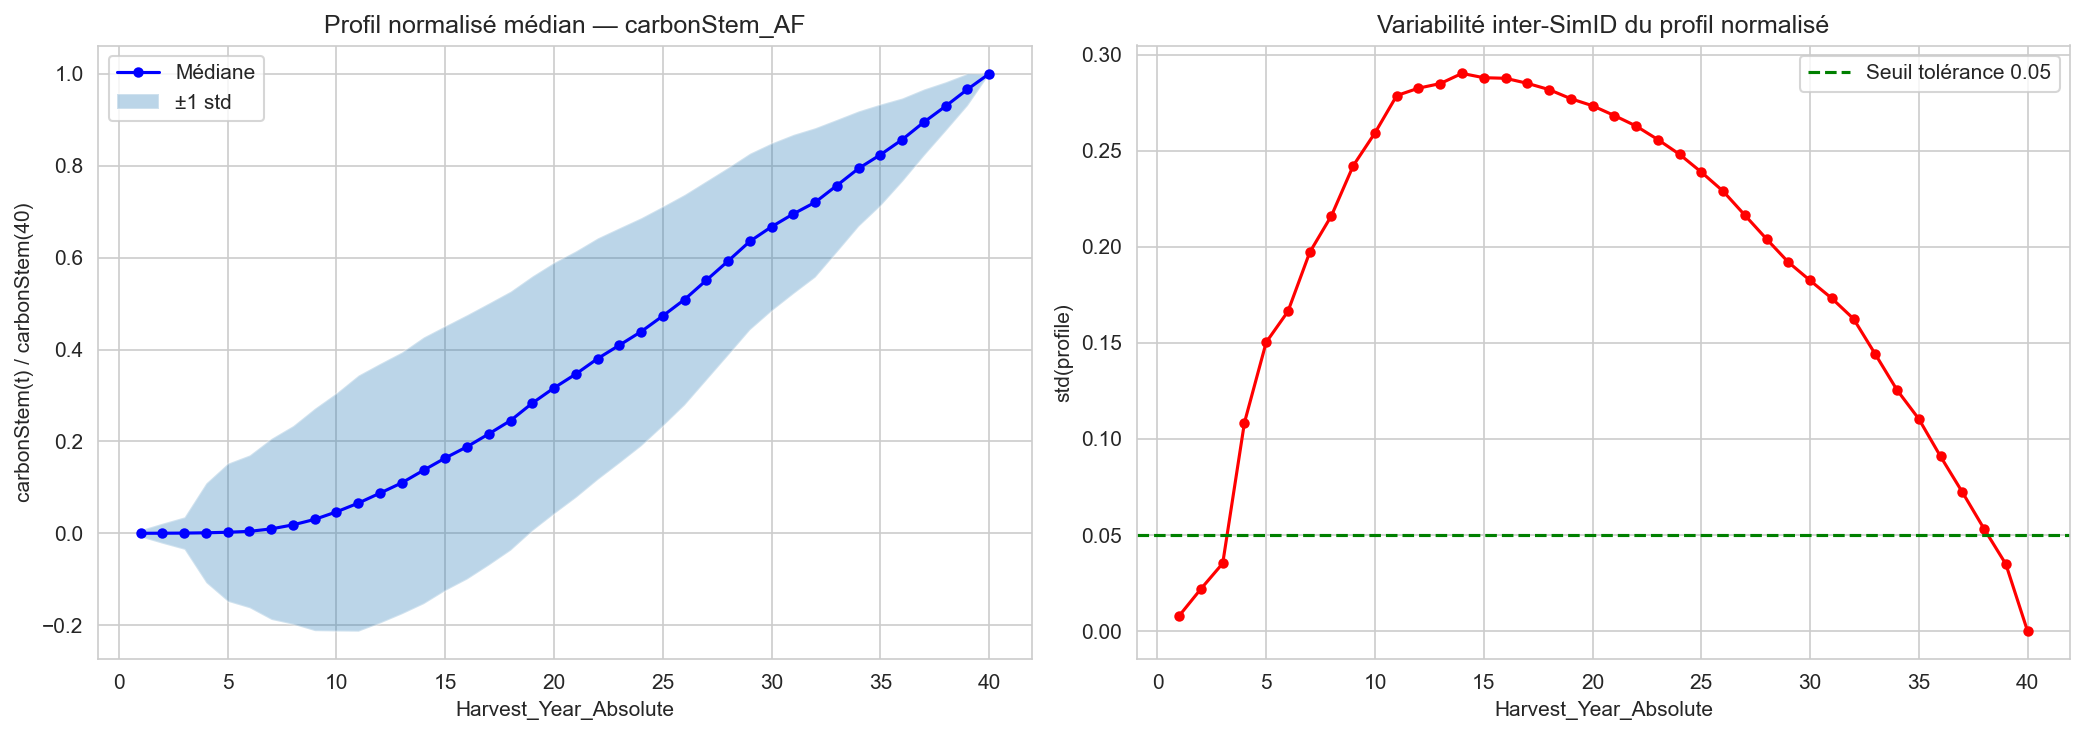

14:20:46 [INFO] metaisafe.notebook — Profil normalisé — std max : 0.290 (year=14) | std médiane : 0.210


In [29]:
# ── Profil normalisé : carbonStem(t) / carbonStem(40) ────────────────────────

df_profile = df_nominal.copy().sort_values(["SimID", "Harvest_Year_Absolute"])

# Stock final par SimID
final_stock = (
    df_profile.groupby("SimID")["carbonStem_AF"]
    .last()
    .rename("carbonStem_AF_final")
)
df_profile = df_profile.join(final_stock, on="SimID")

# Profil normalisé (exclure SimIDs avec stock final nul)
df_profile = df_profile[df_profile["carbonStem_AF_final"] > 1.0].copy()
df_profile["profile_AF"] = (
    df_profile["carbonStem_AF"] / df_profile["carbonStem_AF_final"]
).clip(0, 1)

# Profil médian par année
profile_median = (
    df_profile.groupby("Harvest_Year_Absolute")["profile_AF"]
    .agg(["median", "std", "mean"])
)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(profile_median.index, profile_median["median"], "b-o", ms=4, label="Médiane")
axes[0].fill_between(
    profile_median.index,
    profile_median["median"] - profile_median["std"],
    profile_median["median"] + profile_median["std"],
    alpha=0.3, label="±1 std"
)
axes[0].set_title("Profil normalisé médian — carbonStem_AF")
axes[0].set_xlabel("Harvest_Year_Absolute")
axes[0].set_ylabel("carbonStem(t) / carbonStem(40)")
axes[0].legend()

# Variabilité inter-SimID du profil
profile_std_by_year = df_profile.groupby("Harvest_Year_Absolute")["profile_AF"].std()
axes[1].plot(profile_std_by_year.index, profile_std_by_year.values, "r-o", ms=4)
axes[1].set_title("Variabilité inter-SimID du profil normalisé")
axes[1].set_xlabel("Harvest_Year_Absolute")
axes[1].set_ylabel("std(profile)")
axes[1].axhline(0.05, color="green", linestyle="--", label="Seuil tolérance 0.05")
axes[1].legend()

plt.tight_layout()
plt.show()

log.info(
    "Profil normalisé — std max : %.3f (year=%d) | std médiane : %.3f",
    profile_std_by_year.max(),
    profile_std_by_year.idxmax(),
    profile_std_by_year.median(),
)

In [32]:
# ── Test : modèle SimID-level AVEC features climatiques ──────────────────────

# Agréger les features climatiques par SimID (moyenne sur les 40 cycles)
from column_taxonomy import CLIMATE_FEATURES
climate_feats = CLIMATE_FEATURES
avail_climate = [c for c in climate_feats if c in df_nominal.columns]
log.info("Features climatiques disponibles : %s", avail_climate)

# Agrégation par SimID — moyenne + std sur 40 ans
climate_agg = (
    df_nominal.groupby("SimID")[avail_climate]
    .agg(["mean", "std"])
)
climate_agg.columns = [f"{col}_{stat}" for col, stat in climate_agg.columns]
climate_agg_cols = list(climate_agg.columns)

# Joindre aux features statiques SimID-level
df_final_clim = df_final.join(climate_agg, on="SimID")

log.info(
    "Dataset enrichi : %d SimIDs × %d features (static + climate)",
    len(df_final_clim),
    len(static_feats) + len(climate_agg_cols),
)

# Split
df_final_clim_train = df_final_clim.loc[df_final_train.index]
df_final_clim_test  = df_final_clim.loc[df_final_test.index]

feats_with_climate = static_feats + climate_agg_cols
X_clim_train = df_final_clim_train[feats_with_climate]
X_clim_test  = df_final_clim_test[feats_with_climate]
# Remplacement du bloc fillna
num_feats = [c for c in feats_with_climate 
             if X_clim_train[c].dtype != "category" 
             and X_clim_train[c].dtype.name != "category"]
cat_feats_in_X = [c for c in feats_with_climate 
                  if c not in num_feats]

# Median uniquement sur les numériques
num_medians = X_clim_train[num_feats].median()

X_clim_train[num_feats] = X_clim_train[num_feats].fillna(num_medians)
X_clim_test[num_feats]  = X_clim_test[num_feats].fillna(num_medians)

# Catégorielles : fillna avec le mode
for col in cat_feats_in_X:
    mode_val = X_clim_train[col].mode()[0]
    X_clim_train[col] = X_clim_train[col].fillna(mode_val)
    X_clim_test[col]  = X_clim_test[col].fillna(mode_val)

log.info(
    "NaN restants — train: %d | test: %d",
    X_clim_train.isna().sum().sum(),
    X_clim_test.isna().sum().sum(),
)
y_clim_train = np.log1p(df_final_clim_train["carbonStem_AF"])
y_clim_test  = np.log1p(df_final_clim_test["carbonStem_AF"])

# Modèle
model_clim = build_lgb(categorical_feature=cat_feats_b2)
model_clim.fit(
    X_clim_train, y_clim_train,
    categorical_feature=cat_feats_b2,
)

y_pred_clim = np.expm1(model_clim.predict(X_clim_test))
m_clim = compute_metrics(
    df_final_clim_test["carbonStem_AF"].values,
    y_pred_clim,
    prefix="test_"
)
log.info(
    "Modèle SimID-level + climate — R²=%.3f | RMSE=%.1f | Bias=%.1f",
    m_clim["test_r2"], m_clim["test_rmse"], m_clim["test_bias"],
)

# Comparaison
log.info(
    "Gain R² : %.3f → %.3f  (Δ = +%.3f)",
    0.046, m_clim["test_r2"], m_clim["test_r2"] - 0.046,
)

# Feature importances
imp_clim = get_feature_importances(model_clim, feats_with_climate)
log.info("Top 10 features :\n%s", imp_clim.head(10).to_string())

14:31:12 [INFO] metaisafe.notebook — Features climatiques disponibles : ['GDD_cycle_AF', 'ETP_cycle_AF', 'precipitation_AF', 'frost_events_cycle_AF', 'globalRadiation_AF', 'maxTemperature_extreme_AF', 'minTemperature_extreme_AF']
14:31:12 [INFO] metaisafe.notebook — Dataset enrichi : 948 SimIDs × 25 features (static + climate)
14:31:12 [INFO] metaisafe.notebook — NaN restants — train: 0 | test: 0
14:31:13 [INFO] metaisafe.notebook — Modèle SimID-level + climate — R²=0.229 | RMSE=600.3 | Bias=-134.5
14:31:13 [INFO] metaisafe.notebook — Gain R² : 0.046 → 0.229  (Δ = +0.183)
14:31:13 [INFO] metaisafe.notebook — Top 10 features :
plotHeight                   5124.580259
clay                         3169.628685
soilDepth                    2157.228722
plotWidth                    1991.668551
precipitation_AF_mean        1527.682856
stone                        1505.657730
sand                         1392.537001
longitude                    1163.564164
GDD_cycle_AF_mean            1042.5028

14:35:13 [INFO] metaisafe.notebook — Climate features row-by-row : ['GDD_cycle_AF', 'ETP_cycle_AF', 'precipitation_AF', 'frost_events_cycle_AF', 'globalRadiation_AF', 'maxTemperature_extreme_AF', 'minTemperature_extreme_AF']
14:35:13 [INFO] data.loader — 📐 Dataset built — X: 30360 rows × 19 features | y: 30360 rows × 1 targets
14:35:13 [INFO] data.loader — 📐 Dataset built — X: 7560 rows × 19 features | y: 7560 rows × 1 targets
14:35:13 [INFO] metaisafe.notebook — Row-by-row + climate — train: 25259 rows | test: 6190 rows


Cross-validation:   0%|          | 0/5 [00:00<?, ?it/s]

14:35:18 [INFO] modeling.trainer — 
14:35:18 [INFO] modeling.trainer — CROSS-VALIDATION RESULTS (5 folds)
14:35:18 [INFO] modeling.trainer — ============================================================
14:35:18 [INFO] modeling.trainer — Mean R² train : 0.980
14:35:18 [INFO] modeling.trainer — Mean R² val   : 0.442 ± 0.070
14:35:18 [INFO] modeling.trainer — Mean RMSE val : 1.376
14:35:18 [INFO] modeling.trainer — Mean MAE val  : 1.001
14:35:18 [INFO] modeling.trainer — ============================================================

14:35:18 [INFO] metaisafe.notebook — Row-by-row + climate — CV R²(log) : 0.442 ± 0.070
14:35:18 [INFO] modeling.trainer — 🚀 Training final model on 25259 examples...
14:35:19 [INFO] modeling.trainer — 
14:35:19 [INFO] modeling.trainer — FINAL MODEL METRICS
14:35:19 [INFO] modeling.trainer — ============================================================
14:35:19 [INFO] modeling.trainer — R² train  : 0.975
14:35:19 [INFO] modeling.trainer — RMSE train: 0.293
14:35:

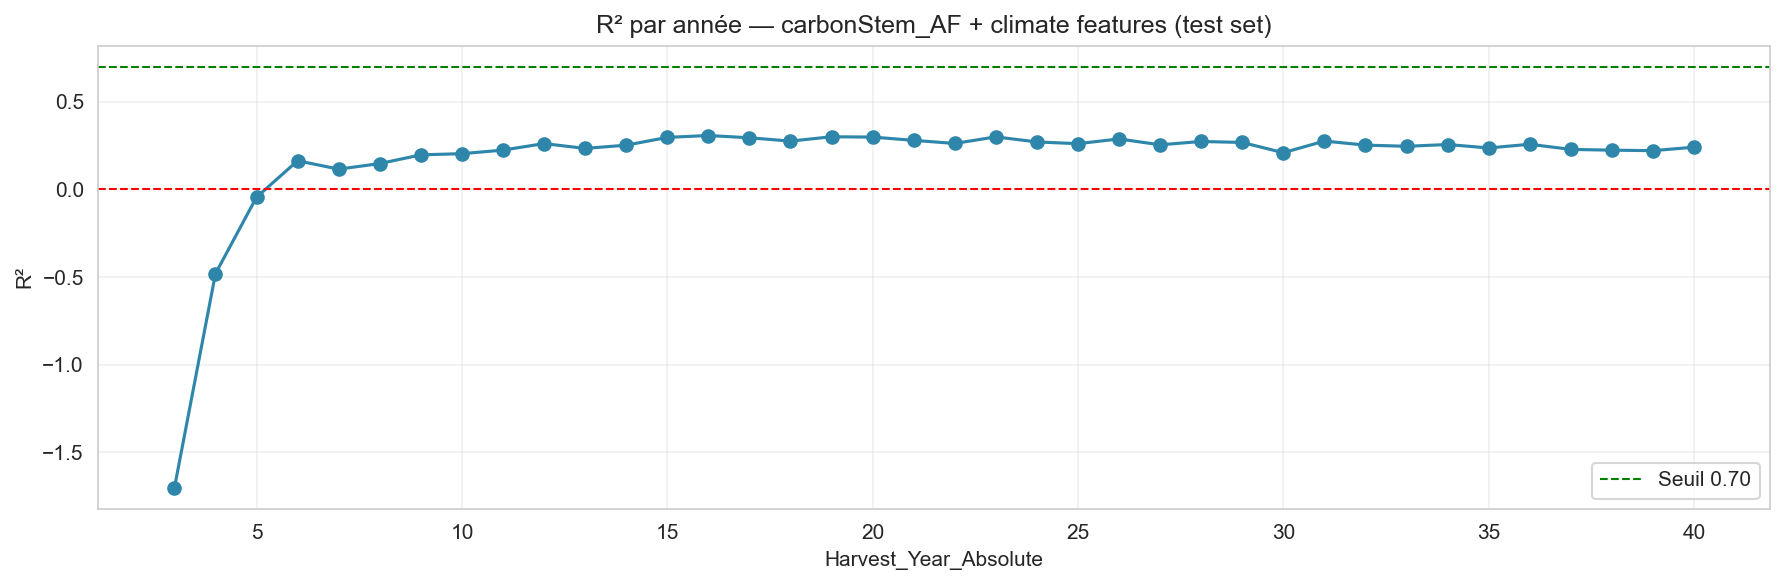

14:35:20 [INFO] metaisafe.notebook — R² par année — min=-1.702 | max=0.307 | mean=0.169
14:35:20 [INFO] metaisafe.notebook — Top 10 features :
Harvest_Year_Absolute    249499.351014
clay                     102534.379089
plotHeight                88379.054457
stone                     67053.976716
latitude                  62511.162922
sand                      54766.925626
plotWidth                 54570.460329
longitude                 49472.142974
soilDepth                 48254.879204
precipitation_AF          24914.496315


In [33]:
# ── Test row-by-row avec features climatiques ────────────────────────────────
# Features = ACTIVE_FEATURES_B2 + CLIMATE_FEATURES (année courante)

from column_taxonomy import CLIMATE_FEATURES

avail_climate_row = [c for c in CLIMATE_FEATURES if c in train_df.columns]
log.info("Climate features row-by-row : %s", avail_climate_row)

feats_with_climate_row = ACTIVE_FEATURES_B2 + avail_climate_row

# Build dataset
X_train_clim, y_train_clim, used_feats_clim, _ = build_dataset(
    train_df,
    features=feats_with_climate_row,
    targets=["carbonStem_AF"],
    verbose=True,
)
X_test_clim, y_test_clim, _, _ = build_dataset(
    test_df,
    features=feats_with_climate_row,
    targets=["carbonStem_AF"],
    verbose=True,
)
y_train_clim = y_train_clim["carbonStem_AF"]
y_test_clim  = y_test_clim["carbonStem_AF"]

# Filtre juvénile
MIN_CARBON = 1.0
mask_train = y_train_clim >= MIN_CARBON
mask_test  = y_test_clim  >= MIN_CARBON

X_train_clim_f = X_train_clim[mask_train]
y_train_clim_f = np.log1p(y_train_clim[mask_train])
X_test_clim_f  = X_test_clim[mask_test]
y_test_clim_f  = np.log1p(y_test_clim[mask_test])

groups_clim = build_cv_groups(train_df[mask_train])

log.info(
    "Row-by-row + climate — train: %d rows | test: %d rows",
    len(y_train_clim_f), len(y_test_clim_f),
)

# Modèle avec régularisation renforcée pour carbonStem
from config import LGB_PARAMS
params_carbon = LGB_PARAMS.copy()
params_carbon.update({
    "num_leaves":        31,    # réduit vs 63 default
    "min_child_samples": 50,    # réduit overfitting
    "reg_alpha":         0.5,
    "reg_lambda":        1.0,
    "subsample":         0.7,
    "colsample_bytree":  0.7,
})

cat_feats_clim = [c for c in CATEGORICAL_FEATURES_B2 if c in used_feats_clim]
model_clim_row = build_lgb(
    params=params_carbon,
    categorical_feature=cat_feats_clim,
)

# CV
cv_clim = cross_validate(
    model_clim_row,
    X_train_clim_f, y_train_clim_f,
    groups=groups_clim,
    cv=make_group_kfold(),
    verbose=True,
)
log.info(
    "Row-by-row + climate — CV R²(log) : %.3f ± %.3f",
    cv_clim["mean_r2_val"], cv_clim["std_r2_val"],
)

# Entraînement final
model_clim_row_fitted, _ = train_final_model(
    model_clim_row,
    X_train_clim_f, y_train_clim_f,
    X_test_clim_f,  y_test_clim_f,
    verbose=True,
)

# Prédictions dans l'espace original
y_pred_clim_row = np.clip(
    np.expm1(model_clim_row_fitted.predict(X_test_clim_f)), 0, None
)
m_clim_row = compute_metrics(
    np.expm1(y_test_clim_f.values), y_pred_clim_row, prefix="test_"
)
log.info(
    "Row-by-row + climate — Test R²(orig)=%.3f | RMSE=%.1f | Bias=%.1f",
    m_clim_row["test_r2"], m_clim_row["test_rmse"], m_clim_row["test_bias"],
)

# R² par année pour diagnostic temporel
test_df_clim_diag = test_df[mask_test].copy()
test_df_clim_diag["y_pred"] = y_pred_clim_row
test_df_clim_diag["y_true"] = np.expm1(y_test_clim_f.values)

from sklearn.metrics import r2_score
r2_by_year_clim = (
    test_df_clim_diag.groupby("Harvest_Year_Absolute")
    .apply(lambda g: r2_score(g["y_true"], g["y_pred"]) if len(g) > 5 else np.nan)
    .rename("r2")
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(r2_by_year_clim.index, r2_by_year_clim.values, "o-", color="#2E86AB")
ax.axhline(0,   color="red",   linestyle="--", linewidth=1)
ax.axhline(0.7, color="green", linestyle="--", linewidth=1, label="Seuil 0.70")
ax.set_xlabel("Harvest_Year_Absolute")
ax.set_ylabel("R²")
ax.set_title("R² par année — carbonStem_AF + climate features (test set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

log.info(
    "R² par année — min=%.3f | max=%.3f | mean=%.3f",
    r2_by_year_clim.min(), r2_by_year_clim.max(), r2_by_year_clim.mean(),
)

# Feature importances
imp_clim_row = get_feature_importances(model_clim_row_fitted, used_feats_clim)
log.info("Top 10 features :\n%s", imp_clim_row.head(10).to_string())

In [ ]:
# ── 5b-2. Récapitulatif stage 1 ───────────────────────────────────────────────
log.info("\n%s", "=" * 60)
log.info("STAGE 1 — RÉCAPITULATIF")
log.info("%-25s  %8s  %8s  %8s", "Target", "CV R²", "Test R²", "Test RMSE")
log.info("%s", "-" * 60)
for target in SEQUENTIAL_TARGETS_STAGE1:
    m = stage1_metrics[target]
    log.info(
        "%-25s  %8.3f  %8.3f  %8.3f",
        target,
        m["mean_r2_val"],
        m["test_r2"],
        m["test_rmse"],
    )
log.info("%s\n", "=" * 60)

# Sanity check : prédictions stage 1 disponibles pour stage 2
assert list(stage1_train_preds.columns) == SEQUENTIAL_TARGETS_STAGE1, \
    "Colonnes stage1_train_preds incorrectes"
assert list(stage1_test_preds.columns)  == SEQUENTIAL_TARGETS_STAGE1, \
    "Colonnes stage1_test_preds incorrectes"
assert len(stage1_train_preds) == len(train_df), \
    "Taille stage1_train_preds incohérente avec train_df"

log.info("✅ Stage 1 complet — prédictions disponibles pour injection stage 2")
log.info(
    "   stage1_train_preds : %d rows × %d cols",
    *stage1_train_preds.shape,
)
log.info(
    "   stage1_test_preds  : %d rows × %d cols",
    *stage1_test_preds.shape,
)

In [ ]:
# # Diagnostic immédiat à lancer
# print("SimIDs train_df :", train_df["SimID"].nunique())
# print("SimIDs test_df  :", test_df["SimID"].nunique())
# print("Intersection    :", len(set(train_df["SimID"]) & set(test_df["SimID"])))
# print("Source df split :", "df_nominal" if len(train_df["SimID"].unique()) < df["SimID"].nunique() else "⚠ df complet")

In [ ]:
# # ── Diagnostic 1 : distribution de carbonStem_AF par année ──────────────────
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Variabilité inter-SimID à année fixe
# for year in [1, 10, 20, 40]:
#     subset = train_df[train_df["Harvest_Year_Absolute"] == year]["carbonStem_AF"]
#     axes[0].hist(subset, bins=40, alpha=0.5, label=f"Year {year}")
# axes[0].set_title("Distribution carbonStem_AF par année (train)")
# axes[0].set_xlabel("carbonStem_AF (kgC/tree)")
# axes[0].legend()

# # Trajectoire moyenne ± std
# yearly = train_df.groupby("Harvest_Year_Absolute")["carbonStem_AF"].agg(["mean", "std"])
# axes[1].plot(yearly.index, yearly["mean"], "b-", label="Mean")
# axes[1].fill_between(
#     yearly.index,
#     yearly["mean"] - yearly["std"],
#     yearly["mean"] + yearly["std"],
#     alpha=0.3, label="±1 std"
# )
# axes[1].set_title("Trajectoire carbonStem_AF (train)")
# axes[1].set_xlabel("Harvest_Year_Absolute")
# axes[1].set_ylabel("carbonStem_AF (kgC/tree)")
# axes[1].legend()
# plt.tight_layout()
# plt.show()

# log.info(
#     "carbonStem_AF — std à year=1 : %.1f | year=20 : %.1f | year=40 : %.1f",
#     train_df[train_df["Harvest_Year_Absolute"]==1]["carbonStem_AF"].std(),
#     train_df[train_df["Harvest_Year_Absolute"]==20]["carbonStem_AF"].std(),
#     train_df[train_df["Harvest_Year_Absolute"]==40]["carbonStem_AF"].std(),
# )

# # ── Diagnostic 2 : R² par année (généralisation temporelle) ─────────────────
# from sklearn.metrics import r2_score

# y_pred_all = stage1_models["carbonStem_AF"].predict(
#     test_df[used_feats]   # used_feats de la dernière itération
# )
# test_df_diag = test_df.copy()
# test_df_diag["y_pred"] = y_pred_all
# test_df_diag["y_true"] = test_df["carbonStem_AF"]

# r2_by_year = (
#     test_df_diag.groupby("Harvest_Year_Absolute")
#     .apply(lambda g: r2_score(g["y_true"], g["y_pred"]))
#     .rename("r2")
# )

# fig, ax = plt.subplots(figsize=(12, 4))
# ax.plot(r2_by_year.index, r2_by_year.values, "o-", color="#2E86AB")
# ax.axhline(0, color="red", linestyle="--", linewidth=1)
# ax.axhline(0.7, color="green", linestyle="--", linewidth=1, label="Seuil 0.70")
# ax.set_xlabel("Harvest_Year_Absolute")
# ax.set_ylabel("R²")
# ax.set_title("R² par année — carbonStem_AF (test set)")
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# log.info("R² par année — min=%.3f | max=%.3f | mean=%.3f",
#     r2_by_year.min(), r2_by_year.max(), r2_by_year.mean()
# )

# # ── Diagnostic 3 : importance des features ───────────────────────────────────
# imp = get_feature_importances(
#     stage1_models["carbonStem_AF"], used_feats
# )
# log.info("Top 5 features carbonStem_AF :\n%s", imp.head(5).to_string())

---
## [5c] STEP 5c — Stage 2 : yield_AF & yield_TA

**Ce qu'on valide ici :**
- Injection des prédictions stage 1 comme features additionnelles
- CV avec `extra_train_features` (prédictions carbonStem stage 1)
- R² test ≥ 0.85

**Note architecturale :** en CV, les prédictions stage 1 sur le fold de validation
doivent être générées par le modèle stage 1 entraîné sur le même fold train — ici
on utilise les prédictions du modèle final (approximation acceptable en première
validation, à affiner si besoin).

In [ ]:
# ── 5c. Stage 2 — yield ───────────────────────────────────────────────────────
stage2_models  = {}
stage2_cv      = {}
stage2_metrics = {}

# Features augmentées = features B2 + prédictions carbonStem stage 1
X_train_s2 = pd.concat(
    [X_train.reset_index(drop=True),
     stage1_preds_train.reset_index(drop=True)],
    axis=1,
)
X_test_s2 = pd.concat(
    [X_test.reset_index(drop=True),
     stage1_preds_test.reset_index(drop=True)],
    axis=1,
)

log.info(
    "Stage 2 — Features augmentées : %d (base %d + %d prédictions stage 1)",
    X_train_s2.shape[1], X_train.shape[1], stage1_preds_train.shape[1],
)

for target in SEQUENTIAL_TARGETS_STAGE2:
    log.info("\n%s", "=" * 60)
    log.info("Stage 2 — Target : %s", target)
    log.info("%s", "=" * 60)

    if target not in y_train_all.columns:
        log.warning("⚠ Target '%s' absent — skipped", target)
        continue

    y_tr = y_train_all[target]
    y_te = y_test_all[target]

    cat_feats = [c for c in CATEGORICAL_FEATURES_B2 if c in X_train_s2.columns]
    model = build_lgb(categorical_feature=cat_feats or None)

    # CV avec features augmentées
    cv_res = cross_validate(
        model, X_train, y_tr, groups=groups, cv=cv,
        extra_train_features=stage1_preds_train.reset_index(drop=True),
        verbose=True,
    )
    stage2_cv[target] = cv_res
    save_cv_results(cv_res, campaign.cv_dir / f"cv_{target}.csv")

    # Entraînement final sur X augmenté
    model_final, metrics = train_final_model(
        build_lgb(categorical_feature=cat_feats or None),
        X_train_s2, y_tr, X_test_s2, y_te, verbose=True,
    )
    stage2_models[target]  = model_final
    stage2_metrics[target] = metrics

    r2_test = metrics.get("r2_test", None)
    if r2_test is not None and r2_test < R2_THRESHOLD:
        log.warning("⚠ %s — R² test = %.3f < seuil %.2f", target, r2_test, R2_THRESHOLD)
    elif r2_test is not None:
        log.info("✅ %s — R² test = %.3f", target, r2_test)

    save_model(
        model_final,
        campaign.metamodels_dir / f"lgbm_{target}.joblib",
        metadata={**metrics, "target": target, "stage": 2,
                  "features": list(X_train_s2.columns)},
    )

log.info("\n✅ Stage 2 complet — %d modèles entraînés", len(stage2_models))

In [ ]:
# ── 5c. Diagnostics visuels Stage 2 ──────────────────────────────────────────
fig, axes = plt.subplots(1, len(stage2_models), figsize=(6 * len(stage2_models), 5))
if len(stage2_models) == 1:
    axes = [axes]

for ax, (target, model) in zip(axes, stage2_models.items()):
    y_pred = model.predict(X_test_s2)
    y_true = y_test_all[target].values
    metrics = compute_metrics(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.3, s=8, color="#52B788")
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, "--", color="#E63946", linewidth=1.5)
    ax.set_title(f"{target}\nR²={metrics['r2']:.3f}  RMSE={metrics['rmse']:.3f}")
    ax.set_xlabel("Observé")
    ax.set_ylabel("Prédit")

plt.suptitle("Stage 2 — Obs vs Pred (test set)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## [5 — Récapitulatif] Tableau de bord des métriques

Vue consolidée R²/RMSE train et test pour tous les modèles.

In [ ]:
# ── Tableau de bord consolidé ─────────────────────────────────────────────────
all_metrics = {**stage1_metrics, **stage2_metrics}
rows = []
for target, m in all_metrics.items():
    stage = 1 if target in SEQUENTIAL_TARGETS_STAGE1 else 2
    rows.append({
        "target":     target,
        "stage":      stage,
        "R²_train":   m.get("r2_train",   None),
        "RMSE_train": m.get("rmse_train", None),
        "R²_test":    m.get("r2_test",    None),
        "RMSE_test":  m.get("rmse_test",  None),
        "MAE_test":   m.get("mae_test",   None),
    })

df_dashboard = pd.DataFrame(rows).set_index("target")

display(
    df_dashboard.round(4)
    .style
    .background_gradient(cmap="RdYlGn", subset=["R²_test"], vmin=0.7, vmax=1.0)
    .background_gradient(cmap="RdYlGn_r", subset=["RMSE_test"])
    .set_caption("Métriques finales — méta-modèle MetAIsAFe B2")
)

# Alerte globale
r2_tests = [m.get("r2_test") for m in all_metrics.values() if m.get("r2_test") is not None]
if r2_tests:
    log.info(
        "R² test — min=%.3f  mean=%.3f  max=%.3f",
        min(r2_tests), sum(r2_tests)/len(r2_tests), max(r2_tests),
    )
    if min(r2_tests) < R2_THRESHOLD:
        log.warning("⚠ Au moins un modèle sous le seuil R² = %.2f", R2_THRESHOLD)

---
## [6] STEP 6 — SHAP

**Ce qu'on valide ici :**
- Calcul des valeurs SHAP pour les 4 modèles régresseurs
- Cohérence feature importance SHAP vs gain LightGBM
- Export CSV pour l'interface RShiny

In [ ]:
# ── 6. SHAP — régresseurs ─────────────────────────────────────────────────────
all_models = {**stage1_models, **stage2_models}

# Construire le bon X de test pour chaque stage
X_test_by_stage = {
    1: X_test,
    2: X_test_s2,
}

shap_results = {}

for target, model in all_models.items():
    stage = 1 if target in SEQUENTIAL_TARGETS_STAGE1 else 2
    X_shap = X_test_by_stage[stage]

    log.info("SHAP — %s (stage %d, %d samples)", target, stage, len(X_shap))

    shap_res = run_shap_analysis(
        model=model,
        X=X_shap,
        target_name=target,
        save_dir=campaign.shap_data_dir,
        verbose=True,
    )
    shap_results[target] = shap_res

    # Validation : dimensions SHAP == dimensions X
    shap_vals = shap_res.get("shap_values")
    if shap_vals is not None:
        assert shap_vals.shape == X_shap.shape, (
            f"SHAP shape {shap_vals.shape} ≠ X shape {X_shap.shape}"
        )
        log.info("✅ SHAP %s — shape OK : %s", target, shap_vals.shape)

log.info("✅ SHAP calculé pour %d modèles", len(shap_results))

In [ ]:
# ── 6b. Visualisation SHAP beeswarm ──────────────────────────────────────────
for target in all_models:
    if target in shap_results and shap_results[target].get("shap_values") is not None:
        plot_shap_by_target(
            shap_values=shap_results[target]["shap_values"],
            X=X_test_by_stage[1 if target in SEQUENTIAL_TARGETS_STAGE1 else 2],
            target_name=target,
            max_display=15,
        )
        plt.show()

In [ ]:
# ── 6c. Cohérence SHAP vs importances LightGBM ────────────────────────────────
from modeling.models import get_feature_importances

for target, model in all_models.items():
    shap_mean = shap_results.get(target, {}).get("mean_abs_shap")
    if shap_mean is None:
        continue

    lgb_imp = get_feature_importances(model, importance_type="gain")

    # Top 5 SHAP vs top 5 LightGBM gain
    top_shap = shap_mean.nlargest(5).index.tolist()
    top_lgb  = lgb_imp.nlargest(5).index.tolist()
    overlap  = set(top_shap) & set(top_lgb)

    log.info(
        "%-25s  Top5 SHAP vs Top5 gain — overlap: %d/5 features",
        target, len(overlap),
    )
    if len(overlap) < 3:
        log.warning(
            "⚠ Faible cohérence SHAP/gain pour '%s' — vérifier la convergence du modèle",
            target,
        )

In [ ]:
# ── 6d. Export SHAP pour RShiny ───────────────────────────────────────────────
for target in all_models:
    if target in shap_results:
        export_shap_for_shiny(
            shap_result=shap_results[target],
            target_name=target,
            save_dir=campaign.shap_data_dir,
        )
log.info("✅ Export SHAP → RShiny terminé")

---
## [7] STEP 7 — Évaluation finale

**Ce qu'on valide ici :**
- Métriques complètes (R², RMSE, MAE, MAPE, NRMSE, Bias, Pearson r)
- Plots obs vs pred, résidus, distribution des erreurs
- Export CSV des métriques et prédictions

In [ ]:
# ── 7. Évaluation complète ────────────────────────────────────────────────────
from modeling.evaluator import (
    compute_metrics, plot_pred_vs_obs,
    plot_residuals, plot_error_distribution,
)
from utils.io_utils import save_predictions

for target, model in all_models.items():
    stage  = 1 if target in SEQUENTIAL_TARGETS_STAGE1 else 2
    X_te   = X_test_by_stage[stage]
    y_true = y_test_all[target].values
    y_pred = model.predict(X_te)

    metrics = compute_metrics(y_true, y_pred)

    log.info(
        "%-25s  R²=%.3f  RMSE=%.3f  MAE=%.3f  Bias=%.3f",
        target,
        metrics["r2"], metrics["rmse"],
        metrics["mae"], metrics["bias"],
    )

    # Sauvegarde métriques et prédictions
    save_metrics(
        metrics,
        campaign.metrics_dir / f"metrics_{target}.csv",
        run_id=f"lgbm_{target}",
    )
    save_predictions(
        y_true, y_pred,
        campaign.predictions_dir / f"predictions_{target}.csv",
    )

    # Plots diagnostics
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    plot_pred_vs_obs(y_true, y_pred, ax=axes[0], title=f"{target} — Obs vs Pred")
    plot_residuals(y_true, y_pred, ax=axes[1], title=f"{target} — Résidus")
    plot_error_distribution(y_true, y_pred, ax=axes[2], title=f"{target} — Distribution erreurs")
    plt.tight_layout()
    plt.savefig(
        campaign.diagnostics_dir / f"diagnostics_{target}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

log.info("✅ Évaluation complète — métriques et plots sauvegardés")

---
## [8] STEP 8 — Inférence test

**Ce qu'on valide ici :**
- Construction d'une grille d'inférence (40 années) depuis un jeu de paramètres utilisateur
- Prédiction complète via `predict_single_sim` (cascade CLF1 → CLF2 → régresseurs)
- Format de sortie compatible RShiny
- Cohérence physique des prédictions (croissance monotone carbonStem, rendement positif)

In [ ]:
# ── 8a. Paramètres utilisateur de test ───────────────────────────────────────
# Scénario représentatif : Montpellier, sol limoneux, blé
USER_PARAMS = {
    "latitude":    43.6,
    "longitude":   3.9,
    "plotWidth":   12.0,
    "plotHeight":  20.0,
    "soilDepth":   1.2,
    "sand":        35.0,
    "clay":        25.0,
    "stone":        5.0,
    "waterTable":   0,
    "main_crop":   "wheat",
    "w_type":      "CONST",
}

log.info("Paramètres inférence : %s", USER_PARAMS)

In [ ]:
# ── 8b. Construction grille d'inférence ───────────────────────────────────────
inference_grid = build_inference_grid(USER_PARAMS, n_years=40)

assert len(inference_grid) == 40, f"Grille d'inférence : {len(inference_grid)} lignes (attendu 40)"
assert "Harvest_Year_Absolute" in inference_grid.columns, "Harvest_Year_Absolute absent"
assert (inference_grid["Harvest_Year_Absolute"] == range(1, 41)).all(), \
    "Harvest_Year_Absolute ne couvre pas [1, 40]"

log.info("✅ Grille d'inférence : %d lignes × %d colonnes", *inference_grid.shape)
display(inference_grid.head(3))

In [ ]:
# ── 8c. Prédiction complète ────────────────────────────────────────────────────
pred_result = predict_single_sim(
    params=USER_PARAMS,
    clf1=clf1_loaded,
    clf2=clf2_loaded,
    stage1_models=stage1_models,
    stage2_models=stage2_models,
    win_bounds=win_bounds,
    feature_cols=ACTIVE_FEATURES_B2,
    cat_features=CATEGORICAL_FEATURES_B2,
    n_years=40,
    verbose=True,
)

# Validation structure de sortie
assert "population" in pred_result, "Clé 'population' absente de pred_result"
assert "predictions" in pred_result, "Clé 'predictions' absente de pred_result"
log.info("Population routée : %s", pred_result["population"])

df_pred = pred_result["predictions"]
log.info("Prédictions : %d lignes × %d colonnes", *df_pred.shape)
display(df_pred.head())

In [ ]:
# ── 8d. Cohérence physique des prédictions ────────────────────────────────────
# carbonStem doit être globalement croissant (stock arboré)
# yield doit être positif

if "carbonStem_AF" in df_pred.columns:
    cs = df_pred["carbonStem_AF"].values
    n_decreases = (np.diff(cs) < -0.5).sum()   # tolérance petite décroissance
    if n_decreases > 5:
        log.warning(
            "⚠ carbonStem_AF : %d baisses significatives sur 40 ans — "
            "vérifier la cohérence de la prédiction",
            n_decreases,
        )
    else:
        log.info("✅ carbonStem_AF globalement croissant")

for col in ["yield_AF", "yield_TA"]:
    if col in df_pred.columns:
        n_neg = (df_pred[col] < 0).sum()
        if n_neg > 0:
            log.warning("⚠ %d valeurs négatives dans '%s'", n_neg, col)
        else:
            log.info("✅ %s : toutes les valeurs ≥ 0", col)

In [ ]:
# ── 8e. Visualisation courbes de prédiction sur 40 ans ───────────────────────
targets_to_plot = [c for c in STOCK_TARGETS_MINIMAL if c in df_pred.columns]
n_plots = len(targets_to_plot)

fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
if n_plots == 1:
    axes = [axes]

years = df_pred["Harvest_Year_Absolute"].values if "Harvest_Year_Absolute" in df_pred.columns \
        else range(1, len(df_pred) + 1)

colors = ["#2E86AB", "#52B788", "#E63946", "#F4A261"]
for ax, col, color in zip(axes, targets_to_plot, colors):
    ax.plot(years, df_pred[col].values, color=color, linewidth=2)
    ax.set_title(col)
    ax.set_xlabel("Année")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Inférence — {USER_PARAMS['main_crop']} | lat={USER_PARAMS['latitude']}°N "
    f"| clay={USER_PARAMS['clay']}%",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

# Format sortie RShiny
shiny_output = format_output(pred_result)
log.info("Format RShiny — clés : %s", list(shiny_output.keys()))
log.info("\n✅ STEP 8 complet — pipeline d'inférence validé")

---
## Récapitulatif final

In [ ]:
# ── Récapitulatif campagne ─────────────────────────────────────────────────────
from utils.io_utils import print_campaign_summary
print_campaign_summary(campaign)

log.info("\n" + "=" * 60)
log.info("VALIDATION COMPLÈTE — MetAIsAFe v4.0")
log.info("=" * 60)
log.info("Campaign   : %s", CAMPAIGN_NAME)
log.info("SimIDs     : %d total | %d nominaux", df["SimID"].nunique(), n_sims_nominal)
log.info("Train/Test : %d / %d SimIDs", len(train_sims), len(test_sims))
log.info("Modèles    : %d régresseurs + 2 classifieurs", len(all_models))

log.info("\nMétriques finales :")
for target, m in all_metrics.items():
    log.info(
        "  %-25s  R²_test=%.3f  RMSE=%.4f",
        target,
        m.get("r2_test", float("nan")),
        m.get("rmse_test", float("nan")),
    )
log.info("=" * 60)